In [1]:
import pandas as pd
import numpy as np

train_1 = pd.read_csv('C:/Users/dpwl1/Downloads/data/data/train/train_1.csv')
train_2 = pd.read_csv('C:/Users/dpwl1/Downloads/data/data/train/train_2.csv')

meta_weather = pd.read_csv('C:/Users/dpwl1/Downloads/data/data/train/meta/TRAIN_기상_2018-2022.csv')
meta_production = pd.read_csv('C:/Users/dpwl1/Downloads/data/data/train/meta/TRAIN_생산정보_2018_2022.csv')
meta_nationwide_market = pd.read_csv('C:/Users/dpwl1/Downloads/data/data/train/meta/TRAIN_경락정보_전국도매_2018-2022.csv')
meta_retail = pd.read_csv('C:/Users/dpwl1/Downloads/data/data/train/meta/TRAIN_소매_2018-2022.csv')
meta_wholesale = pd.read_csv('C:/Users/dpwl1/Downloads/data/data/train/meta/TRAIN_중도매_2018-2022.csv')

print("train_1 head:")
print(train_1.head())
print("\ntrain_2 head:")
print(train_2.head())
print("\nweather head:")
print(meta_weather.head())
print("\nproduction head:")
print(meta_production.head())
print("\nnationwide_market head:")
print(meta_nationwide_market.head())
print("\nretail head:")
print(meta_retail.head())
print("\nwholesale head:")
print(meta_wholesale.head())


train_1 head:
  YYYYMMSOON  가락시장 품목코드(5자리) 품목(품종)명    거래단위 등급(특 5% 상 35% 중 40% 하 20%)  \
0   201801상순           21100      배추  10키로망대                          상   
1   201801중순           21100      배추  10키로망대                          상   
2   201801하순           21100      배추  10키로망대                          상   
3   201802상순           21100      배추  10키로망대                          상   
4   201802중순           21100      배추  10키로망대                          상   

       평균가격(원)  전순 평균가격(원) PreVious SOON  전달 평균가격(원) PreVious MMonth  \
0  5419.857143               5293.333333                 5242.125000   
1  5319.333333               5419.857143                 5553.222222   
2  6734.777778               5319.333333                 5293.333333   
3  8942.222222               6734.777778                 5419.857143   
4  7247.166667               8942.222222                 5319.333333   

   전년 평균가격(원) PreVious YeaR  평년 평균가격(원) Common Year SOON  
0               9213.428571                

In [2]:
# diff year, mm, soon
def datetime_cov(df):
    df['year'] = df['YYYYMMSOON'].str.slice(0,4).astype(int)
    df['month'] = df['YYYYMMSOON'].str.slice(4,6).astype(int)
    df['soon'] = df['YYYYMMSOON'].str.slice(6)

    # mapping 하중상
    period_mapping = {'상순': 1, '중순': 11, '하순': 21}
    df['day'] = df['soon'].map(period_mapping)

    df = df.dropna(subset=['day'])
    df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
    
    return df

train_1 = datetime_cov(train_1)
train_2 = datetime_cov(train_2)
meta_weather = datetime_cov(meta_weather)
meta_retail = datetime_cov(meta_retail)
# meta_production = datetime_cov(meta_production) : doesnt have YYYYYMMSOON
meta_wholesale = datetime_cov(meta_wholesale)



print("train_1 head:")
print(train_1.head())
print("\ntrain_2 head:")
print(train_2.head())
print("\nweather head:")
print(meta_weather.head())


train_1 head:
  YYYYMMSOON  가락시장 품목코드(5자리) 품목(품종)명    거래단위 등급(특 5% 상 35% 중 40% 하 20%)  \
0   201801상순           21100      배추  10키로망대                          상   
1   201801중순           21100      배추  10키로망대                          상   
2   201801하순           21100      배추  10키로망대                          상   
3   201802상순           21100      배추  10키로망대                          상   
4   201802중순           21100      배추  10키로망대                          상   

       평균가격(원)  전순 평균가격(원) PreVious SOON  전달 평균가격(원) PreVious MMonth  \
0  5419.857143               5293.333333                 5242.125000   
1  5319.333333               5419.857143                 5553.222222   
2  6734.777778               5319.333333                 5293.333333   
3  8942.222222               6734.777778                 5419.857143   
4  7247.166667               8942.222222                 5319.333333   

   전년 평균가격(원) PreVious YeaR  평년 평균가격(원) Common Year SOON  year  month soon  \
0               9213.428

In [3]:
meta_production.head()

,년도,품목명,재배면적(ha),생산량(톤)
0,2018,배추,31143,2391946
1,2018,상추,3773,93543
2,2019,배추,25837,1859705
3,2019,상추,3629,95582
4,2020,배추,30949,2242640


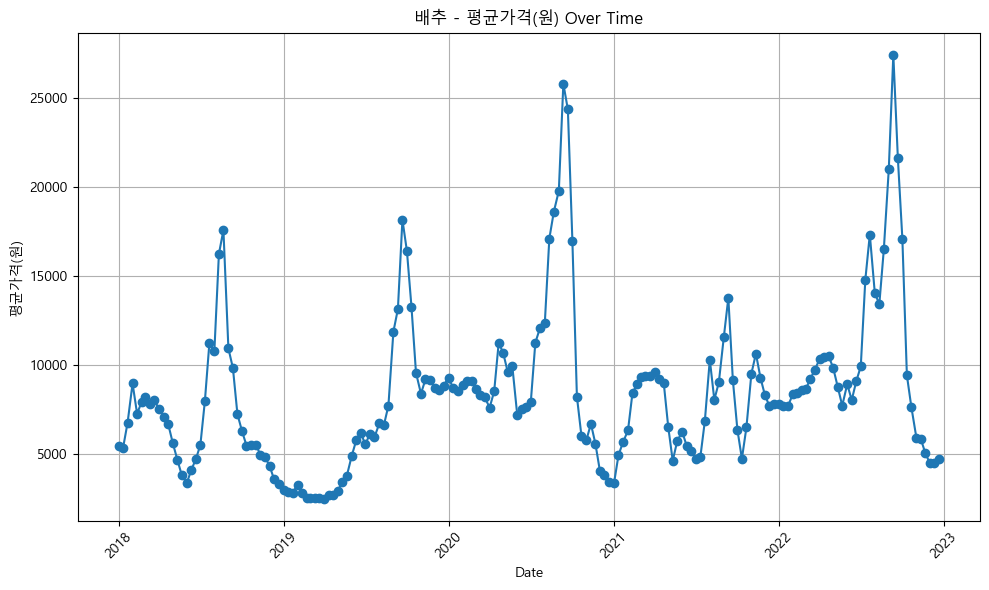

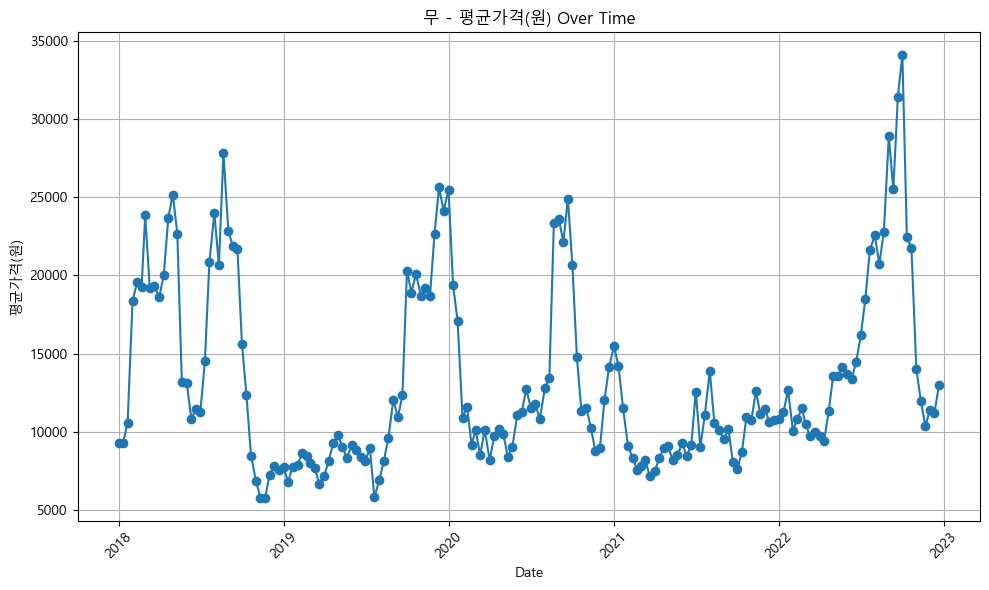

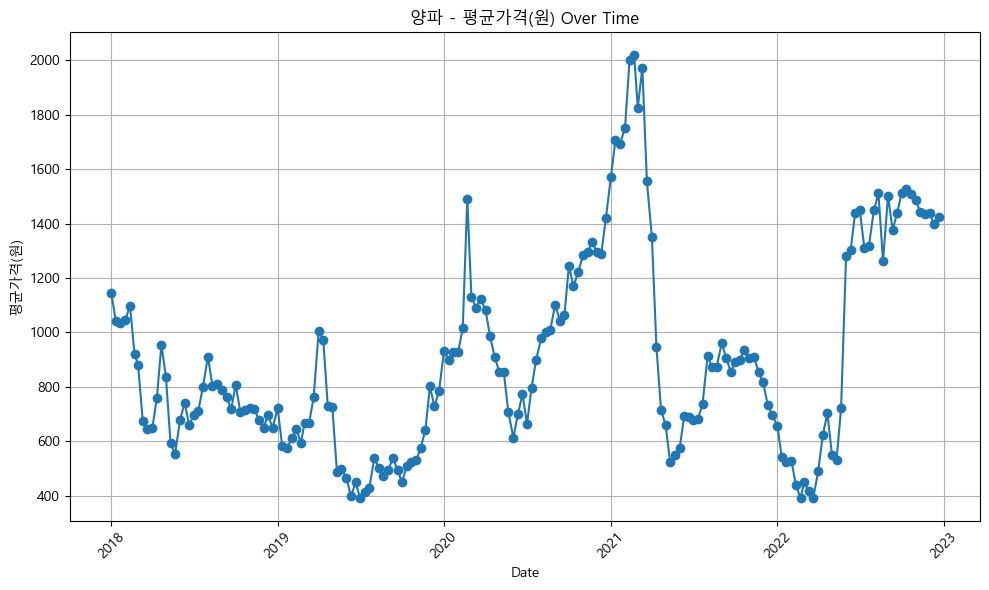

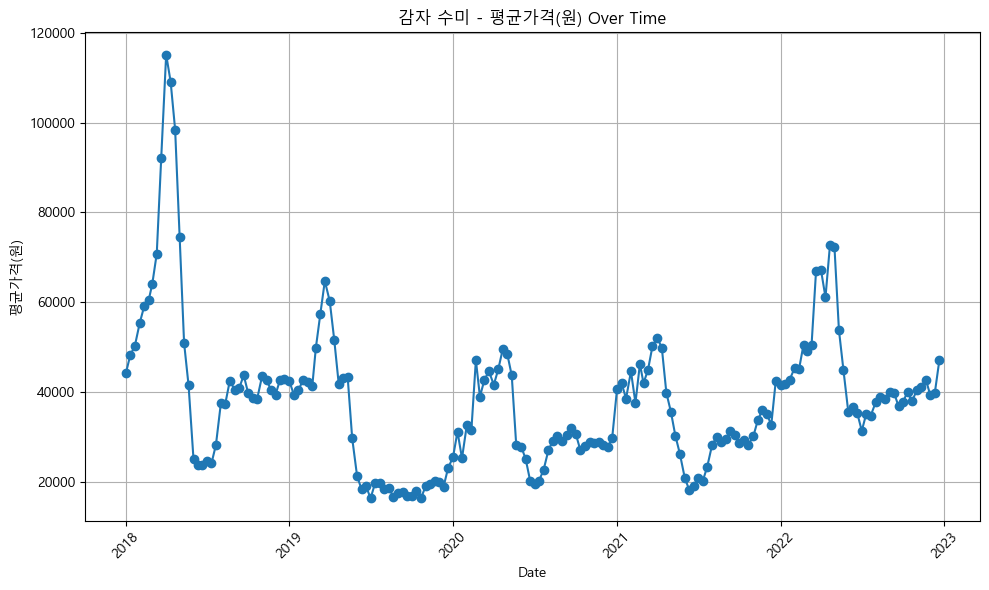

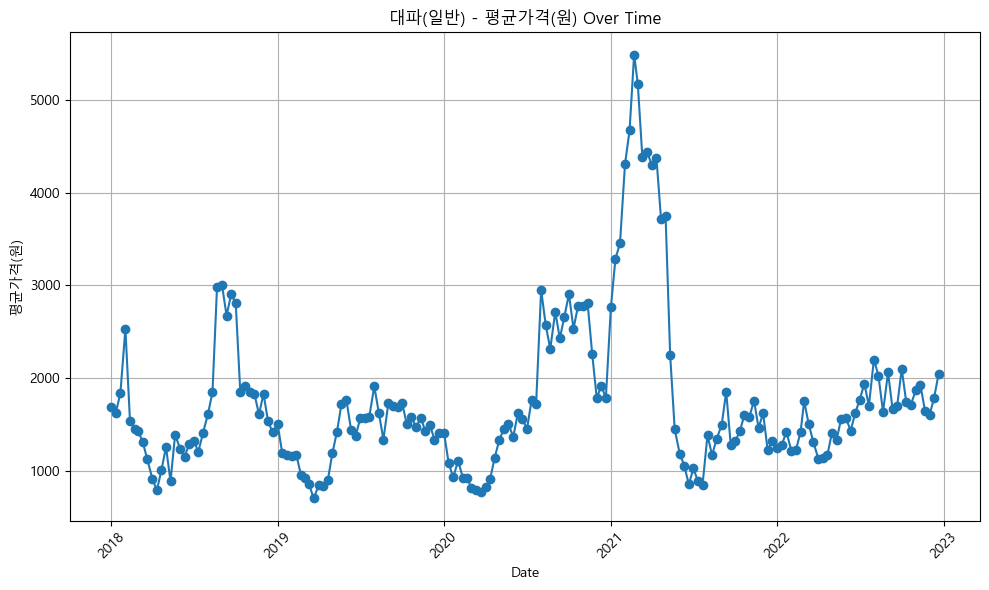

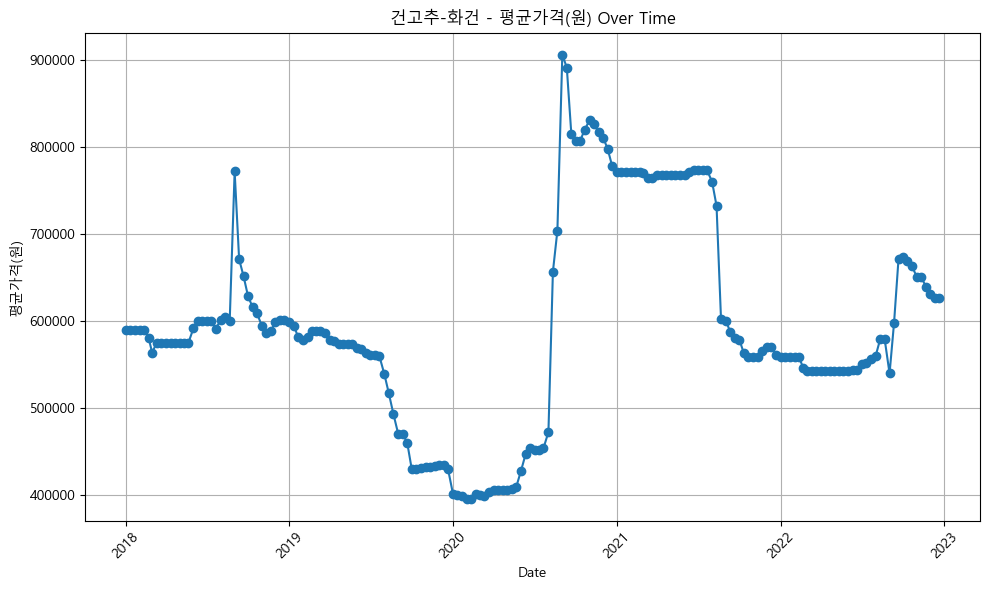

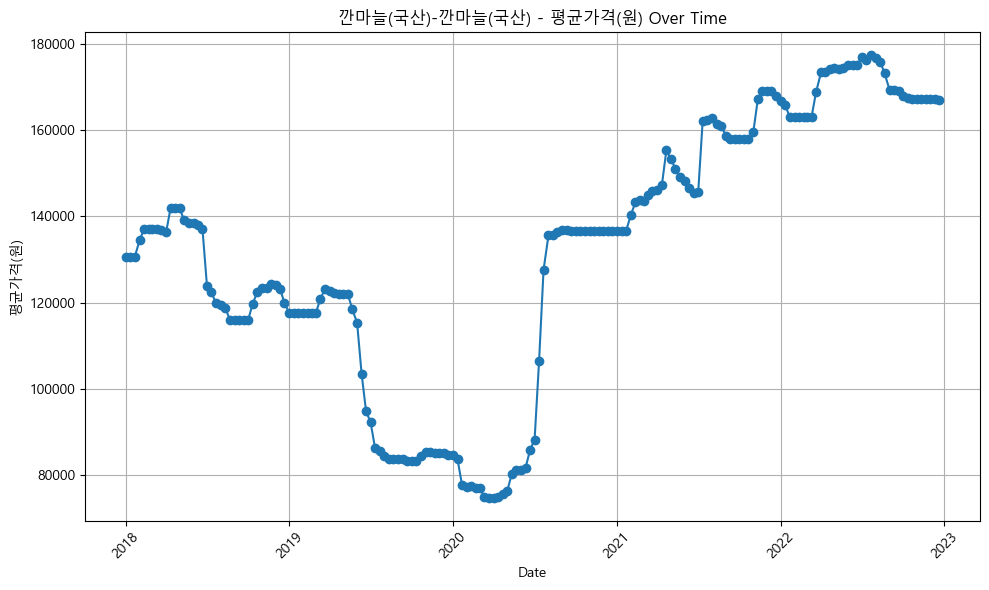

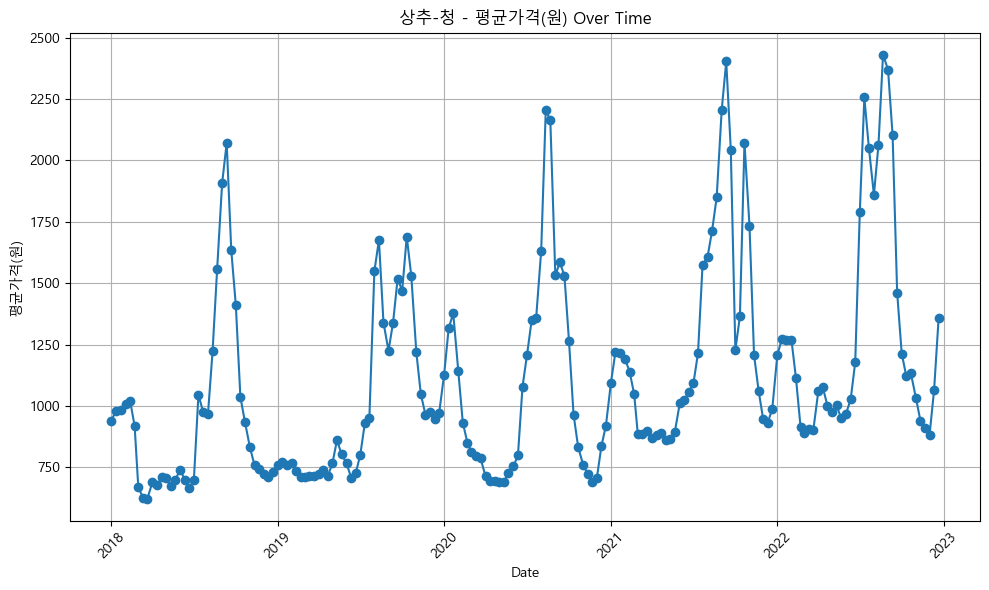

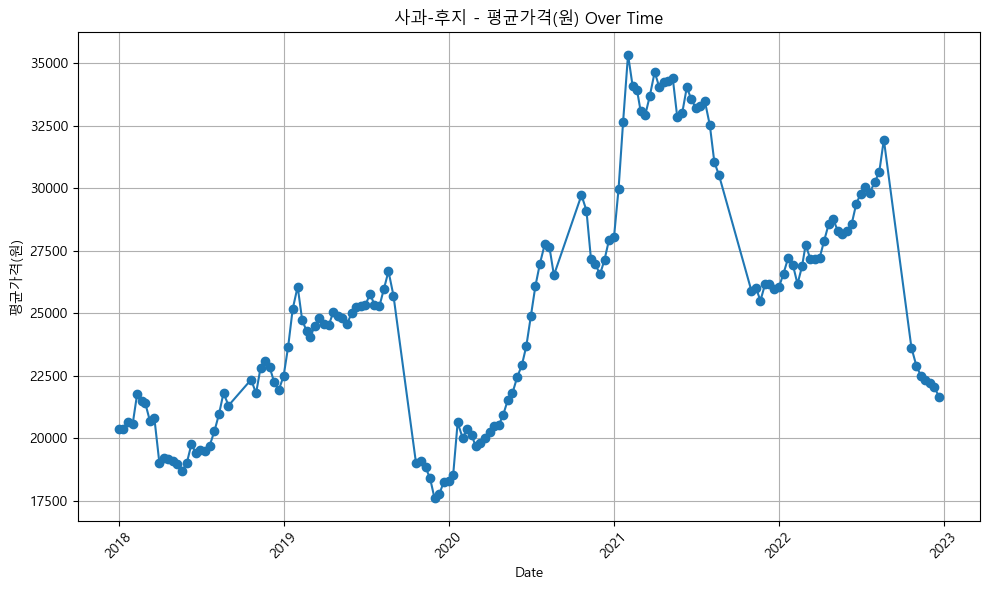

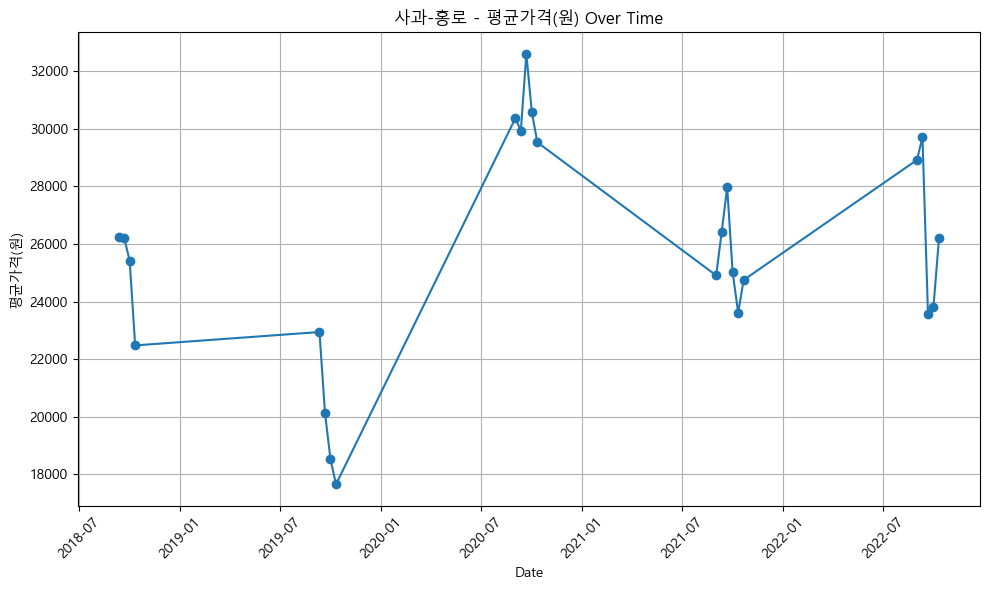

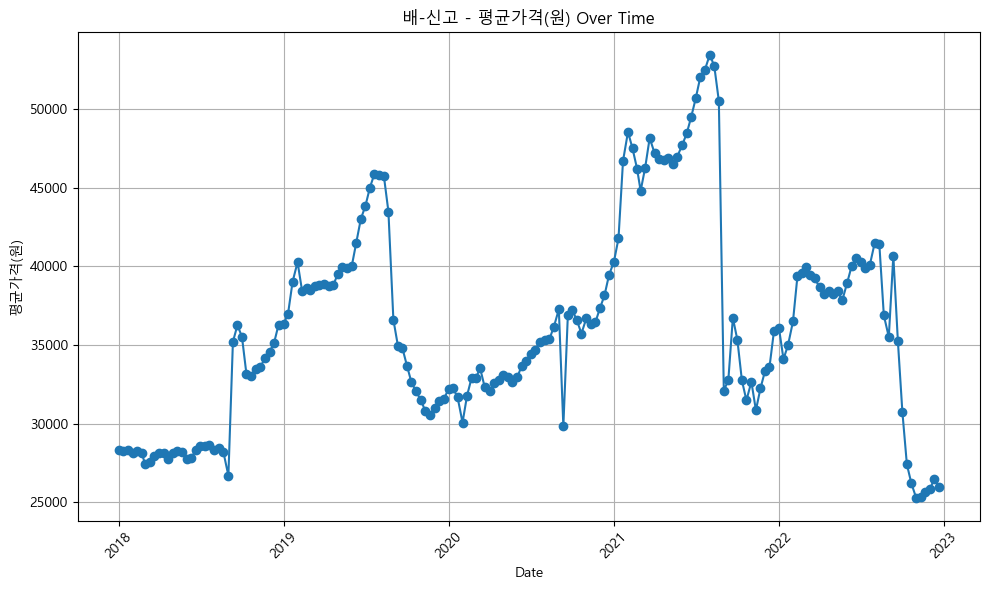

In [4]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 마이너스 폰트 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

train_1['품목-품종'] = train_1['품목(품종)명']
train_2['품목-품종'] = train_2['품목명'] + '-' + train_2['품종명']


def plot_data_by_product(df, date_col, product_col, value_col):
    product_varieties = df[product_col].unique()
    for pv in product_varieties:
        subset = df[df[product_col] == pv]
        plt.figure(figsize=(10, 6))
        plt.plot(subset[date_col], subset[value_col], marker='o')
        plt.title(f'{pv} - {value_col} Over Time')
        plt.xlabel('Date')
        plt.ylabel(value_col)
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Plot data for train_1
plot_data_by_product(train_1, 'date', '품목-품종', '평균가격(원)')

# Plot data for train_2
plot_data_by_product(train_2, 'date', '품목-품종', '평균가격(원)')

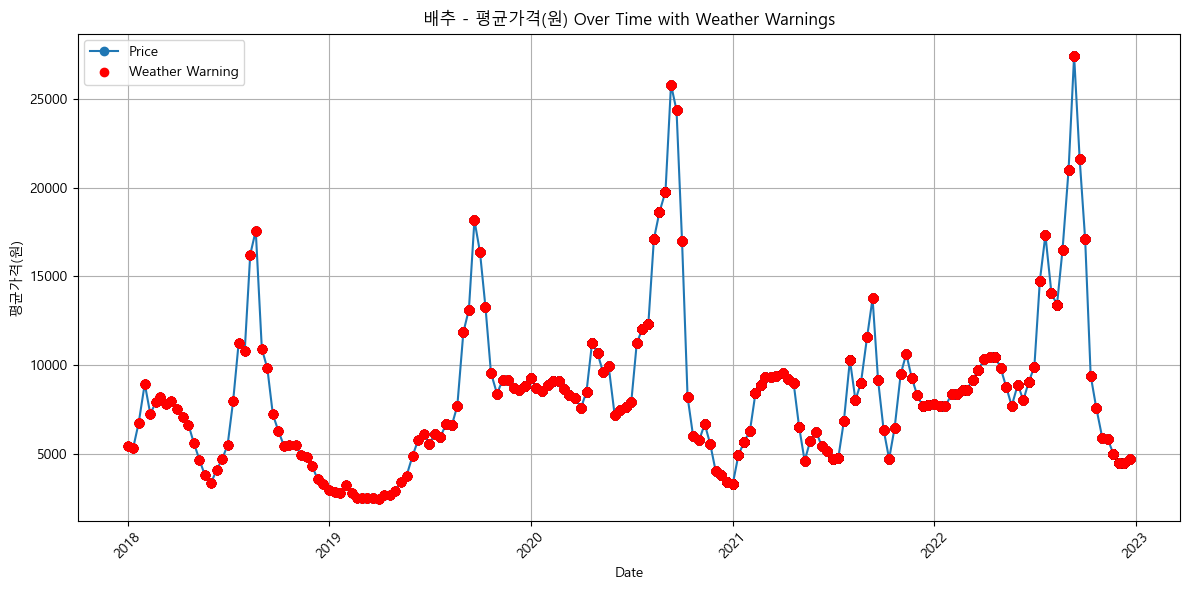

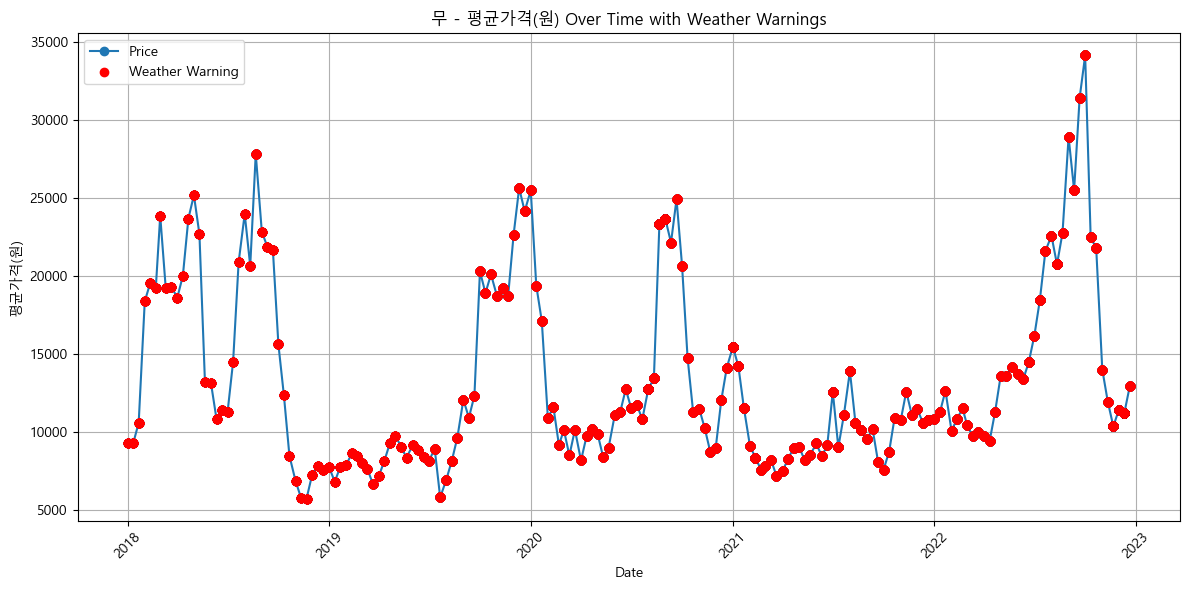

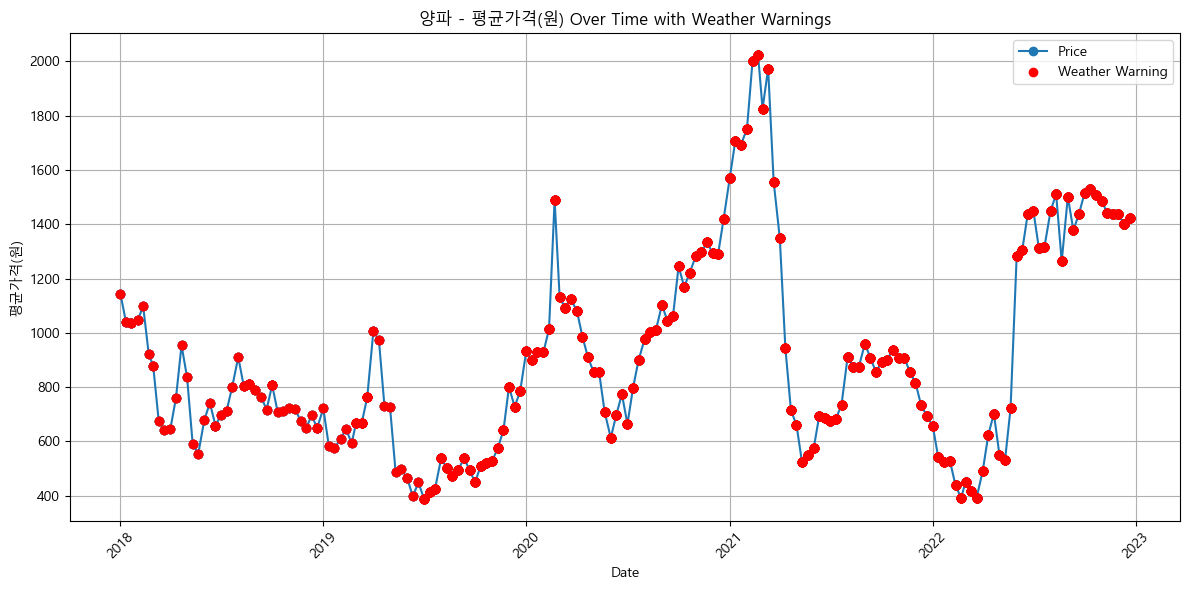

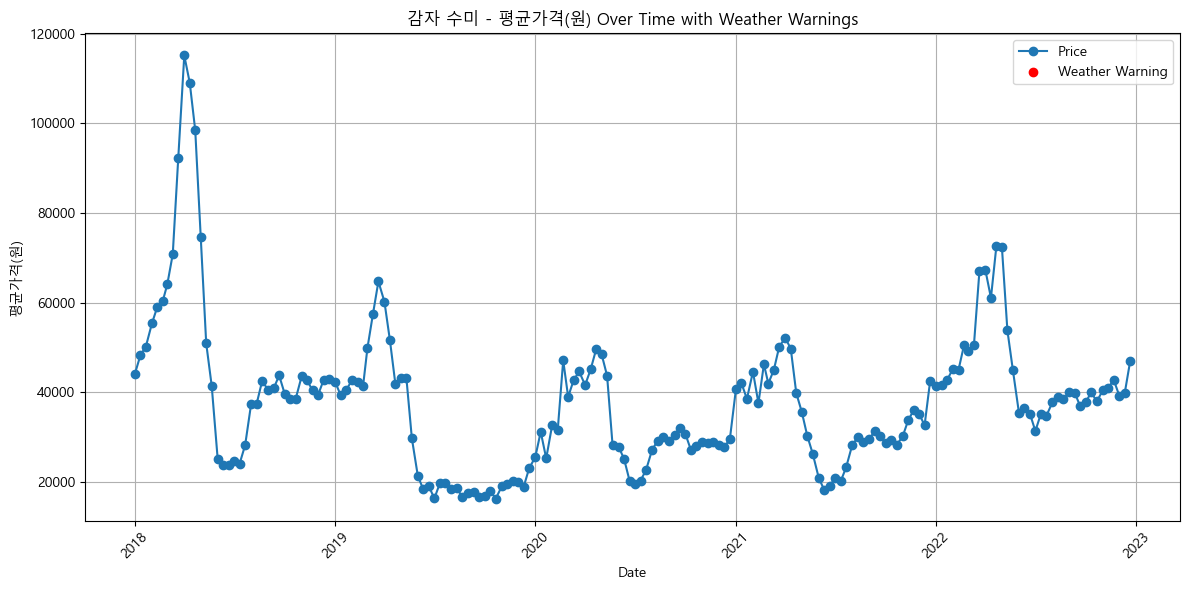

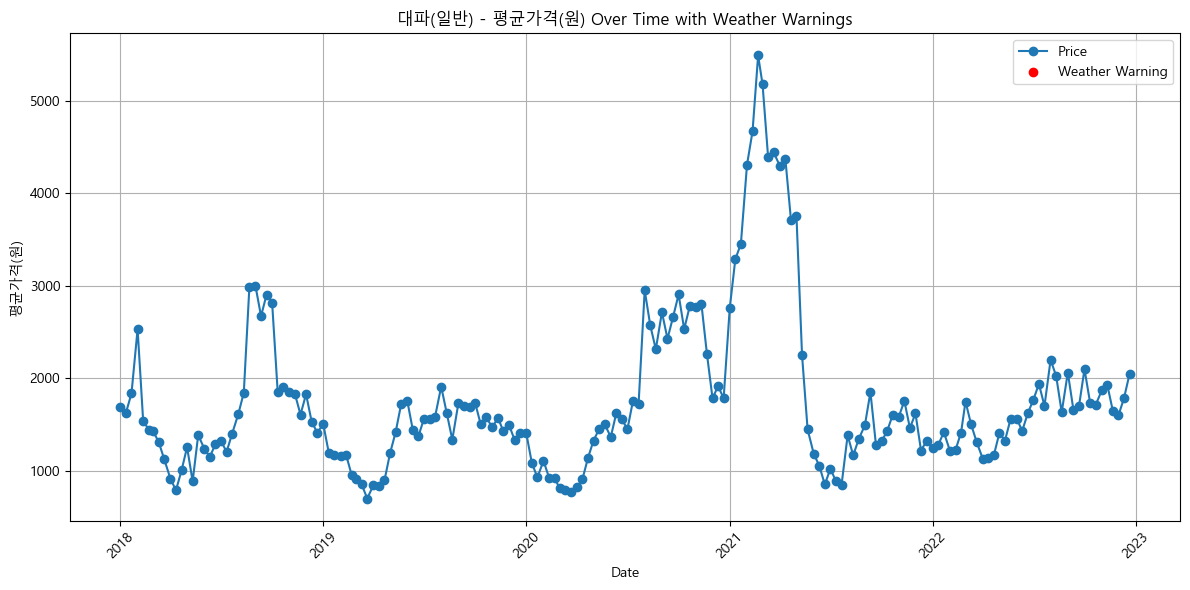

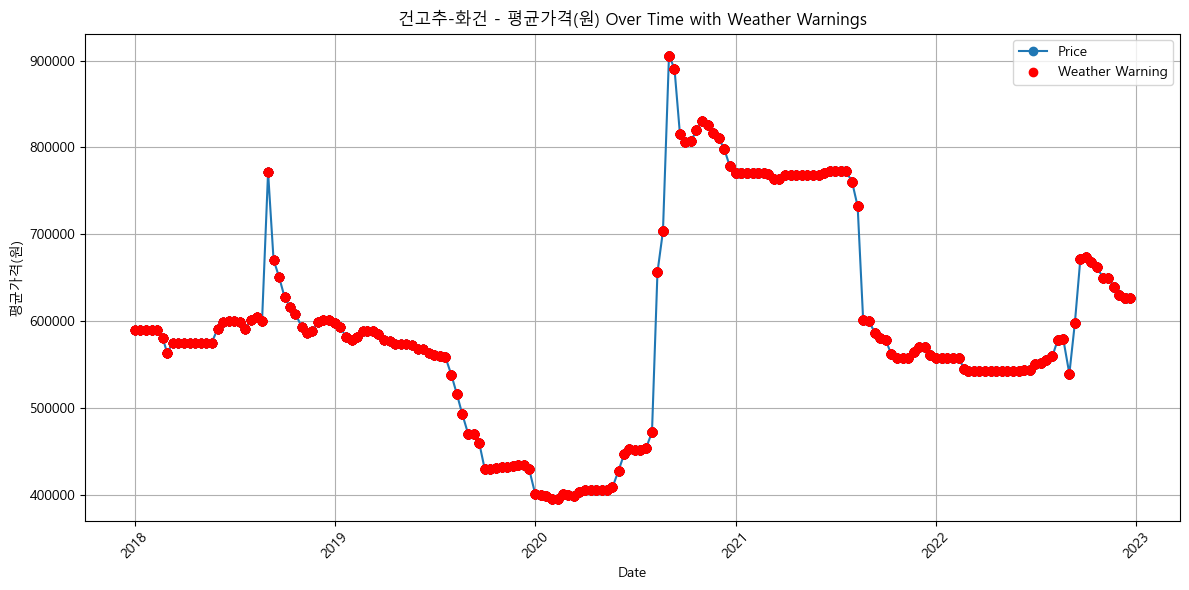

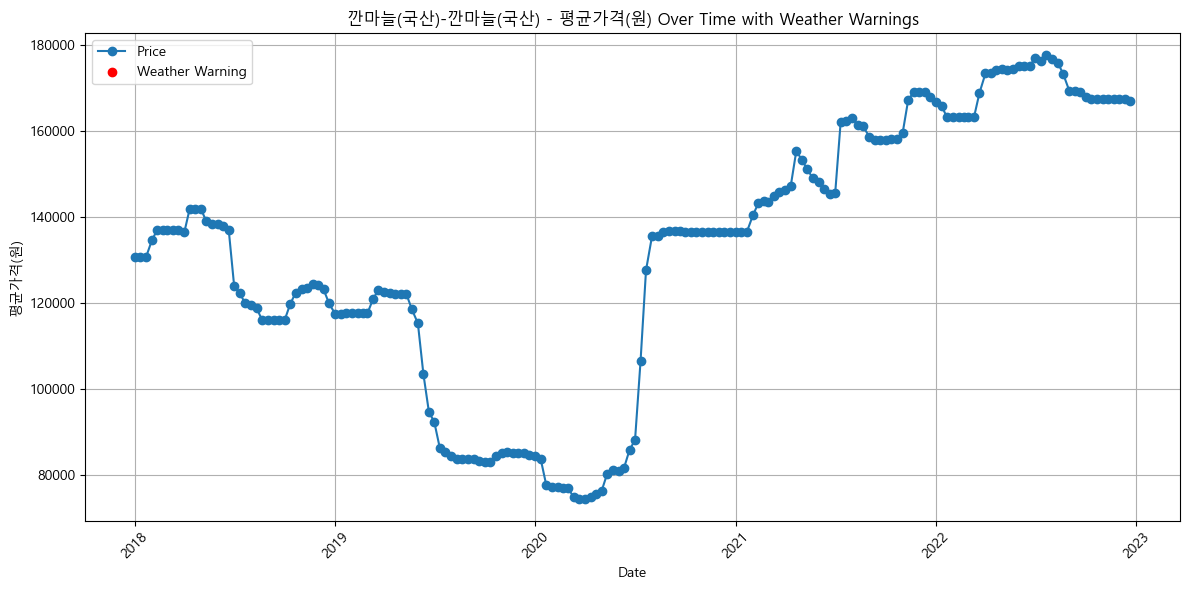

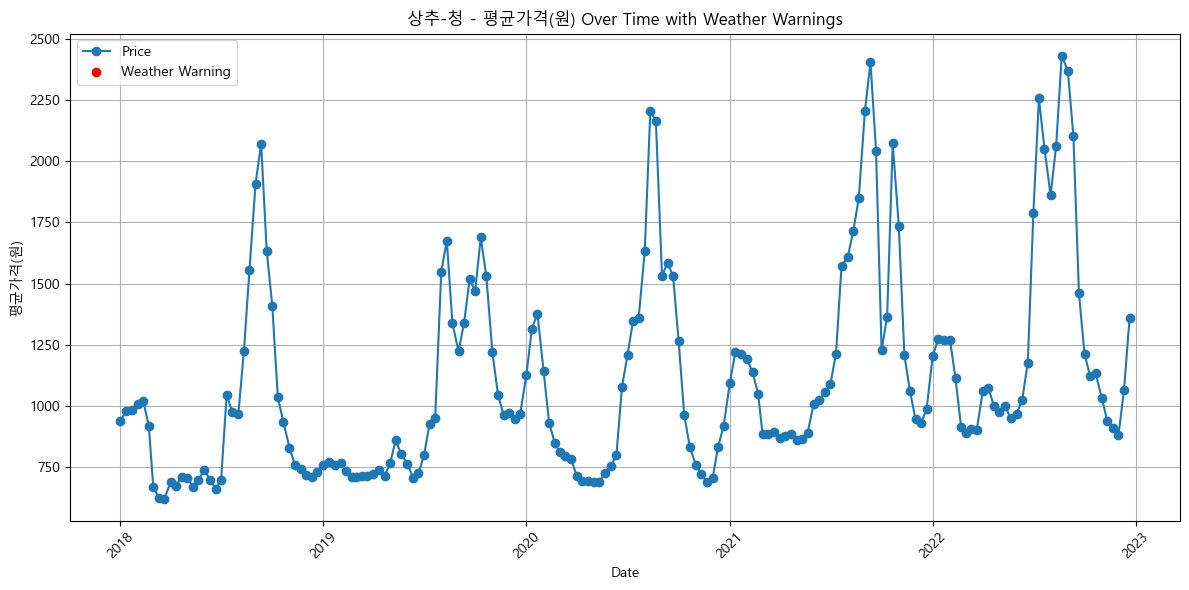

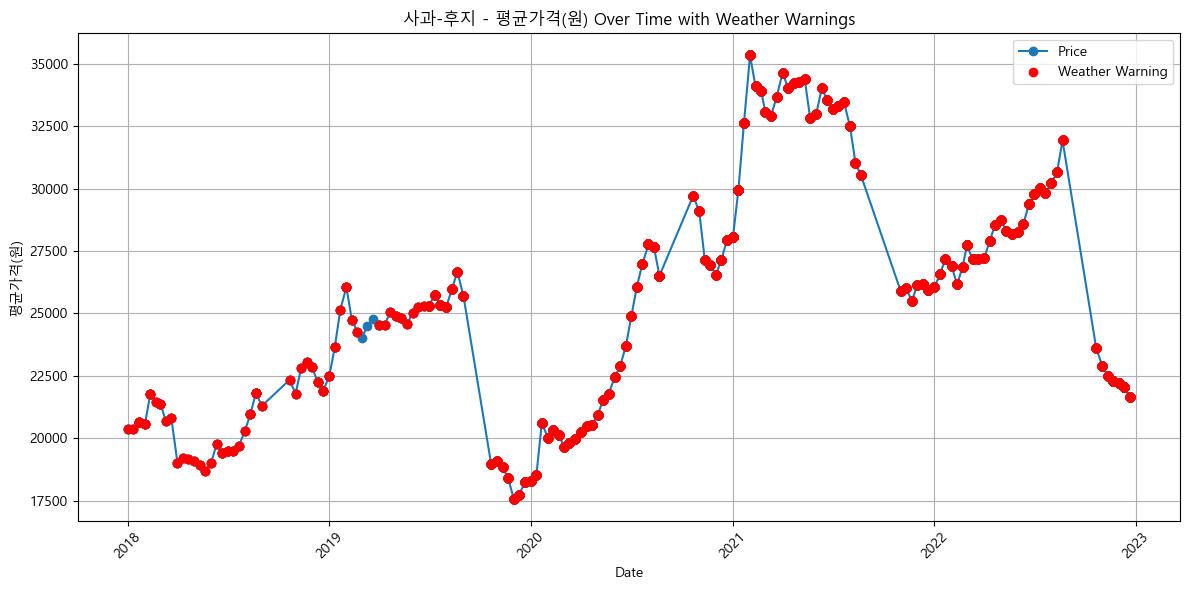

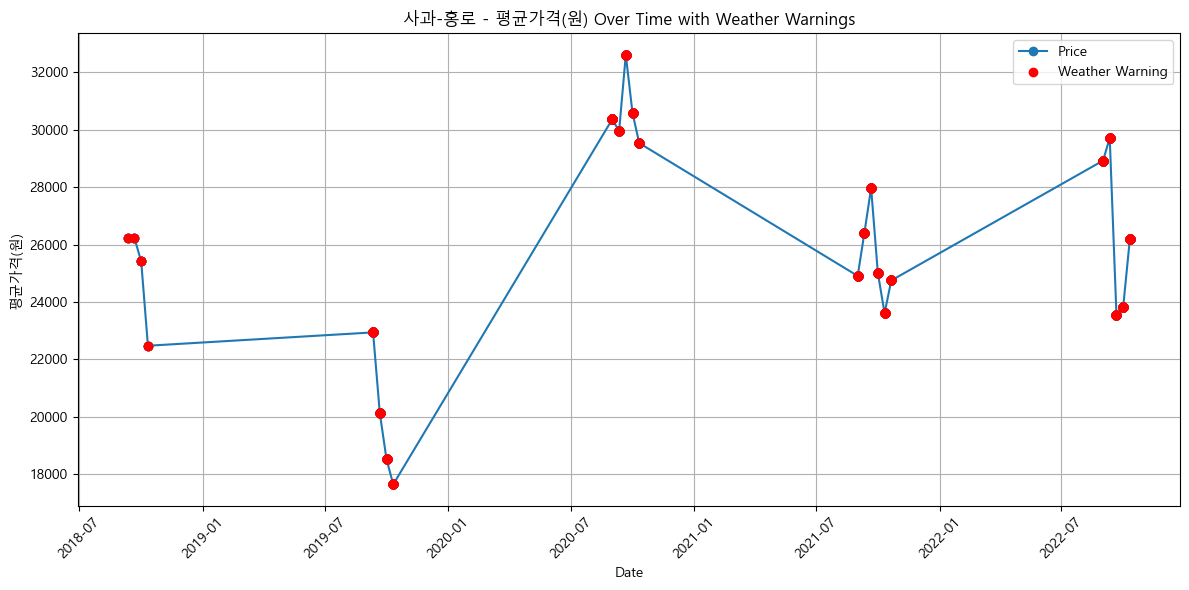

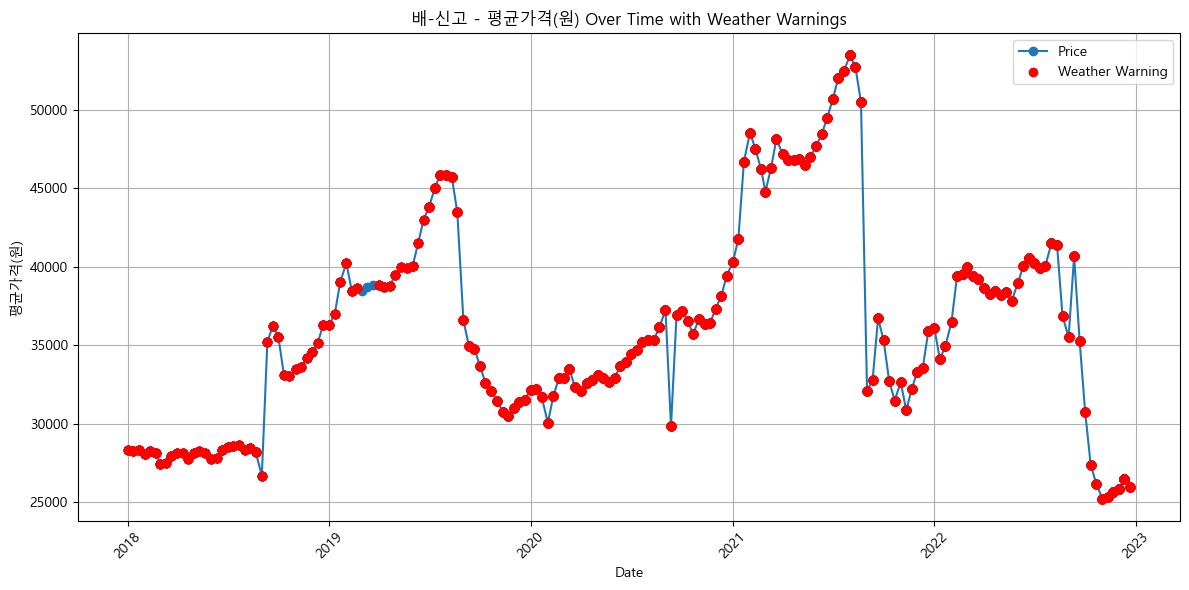

In [5]:
# 계절 특보와 상관 관계
train_1['품목명'] = train_1['품목(품종)명'] 
weather_cols = ['date', '주산지 품목명', '주산지 품종명', '지역 이름', '특보 명']
weather_data = meta_weather[weather_cols].drop_duplicates()
weather_data.rename(columns={'주산지 품목명': '품목명', '주산지 품종명': '품종명'}, inplace=True)

train_1_merged = pd.merge(train_1, weather_data, on=['date', '품목명'], how='left')
train_2_merged = pd.merge(train_2, weather_data, on=['date', '품목명'], how='left')

# Add flag for presence of '특보 명'
train_1_merged['특보명 존재'] = train_1_merged['특보 명'].notnull().astype(int)
train_2_merged['특보명 존재'] = train_2_merged['특보 명'].notnull().astype(int)


def plot_data_with_weather_flag(df, date_col, product_col, value_col, weather_flag_col):
    product_varieties = df[product_col].unique()
    for pv in product_varieties:
        subset = df[df[product_col] == pv]
        plt.figure(figsize=(12, 6))
        plt.plot(subset[date_col], subset[value_col], marker='o', label='Price')
        
        # Mark points where '특보명' exists
        weather_dates = subset[subset[weather_flag_col] == 1][date_col]
        weather_prices = subset[subset[weather_flag_col] == 1][value_col]
        plt.scatter(weather_dates, weather_prices, color='red', label='Weather Warning', zorder=5)
        
        plt.title(f'{pv} - {value_col} Over Time with Weather Warnings')
        plt.xlabel('Date')
        plt.ylabel(value_col)
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


plot_data_with_weather_flag(train_1_merged, 'date', '품목-품종', '평균가격(원)', '특보명 존재')
plot_data_with_weather_flag(train_2_merged, 'date', '품목-품종', '평균가격(원)', '특보명 존재')

data-adding features

In [6]:
print("train_1 head:")
print(train_1.head(0))
print("\ntrain_2 head:")
print(train_2.head(0))
print("\nweather head:")
print(meta_weather.head(0))
print("\nproduction head:")
print(meta_production.head(0))
print("\nnationwide_market head:")
print(meta_nationwide_market.head(0))
print("\nretail head:")
print(meta_retail.head(0))
print("\nwholesale head:")
print(meta_wholesale.head(0))

train_1 head:
Empty DataFrame
Columns: [YYYYMMSOON, 가락시장 품목코드(5자리), 품목(품종)명, 거래단위, 등급(특 5% 상 35% 중 40% 하 20%), 평균가격(원), 전순 평균가격(원) PreVious SOON, 전달 평균가격(원) PreVious MMonth, 전년 평균가격(원) PreVious YeaR, 평년 평균가격(원) Common Year SOON, year, month, soon, day, date, 품목-품종, 품목명]
Index: []

train_2 head:
Empty DataFrame
Columns: [YYYYMMSOON, 품목코드 , 품목명, 품종코드 , 품종명, 등급명, 유통단계별 무게 , 유통단계별 단위 , 평균가격(원), 전순 평균가격(원) PreVious SOON, 전달 평균가격(원) PreVious MMonth, 전년 평균가격(원) PreVious YeaR, 평년 평균가격(원) Common Year SOON, year, month, soon, day, date, 품목-품종]
Index: []

weather head:
Empty DataFrame
Columns: [YYYYMMSOON, 지역 이름, 주산지 품목명, 주산지 품종명, 순 평균상대습도, 순 평균기온, 순 평균풍속, 순 최고기온, 순 최저상대습도, 순 최저기온, 순 강수량, 순 누적 일조시간, 특보 코드, 특보 명, 특보 발효 순통계 개수, year, month, soon, day, date]
Index: []

production head:
Empty DataFrame
Columns: [년도, 품목명, 재배면적(ha), 생산량(톤)]
Index: []

nationwide_market head:
Empty DataFrame
Columns: [YYYYMMSOON, 시장코드, 시장명, 품목코드, 품목명, 품종코드, 품종명, 총반입량(kg), 총거래금액(원), 평균가(원/kg), 고가(20%) 평균가, 중가(60%) 평균가 , 

In [7]:
missing_value_columns_train = ['평균가격(원)', '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth','전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON']
missing_value_columns_meta_weather = ['순 평균상대습도', '순 평균기온', '순 평균풍속', '순 최고기온', '순 최저상대습도', '순 최저기온', '순 강수량', '순 누적 일조시간']
missing_value_columns_meta_production = ['생산량(톤)', '재배면적(ha)']
missing_value_columns_meta_market = ['평균가(원/kg)', '고가(20%) 평균가', '중가(60%) 평균가 ', '저가(20%) 평균가', '중간가(원/kg)', '최저가(원/kg)', '최고가(원/kg)', '경매 건수', '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth', '전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON']
missing_value_columns_meta_whole = ['유통단계별 무게 ', '유통단계별 단위 ', '평균가격(원)','전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth', '전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON']
# Replace zeros with NaN
train_1[missing_value_columns_train] = train_1[missing_value_columns_train].replace(0, np.nan)
train_2[missing_value_columns_train] = train_2[missing_value_columns_train].replace(0, np.nan)
meta_weather[missing_value_columns_meta_weather] = meta_weather[missing_value_columns_meta_weather].replace(0, np.nan)
meta_production[missing_value_columns_meta_production] = meta_production[missing_value_columns_meta_production].replace(0, np.nan)
meta_nationwide_market[missing_value_columns_meta_market] = meta_nationwide_market[missing_value_columns_meta_market].replace(0, np.nan)
meta_wholesale[missing_value_columns_meta_whole] = meta_wholesale[missing_value_columns_meta_whole].replace(0, np.nan)

def count_nans_and_rows(df, group_columns, missing_value_columns):
    nan_counts = df.groupby(group_columns)[missing_value_columns].apply(lambda x: x.isna().sum())
    total_counts = df.groupby(group_columns).size().rename("Total Rows")
    return pd.concat([nan_counts, total_counts], axis=1)

nan_counts_train_1 = count_nans_and_rows(train_1, ['품목(품종)명'], missing_value_columns_train)
nan_counts_train_2 = count_nans_and_rows(train_2, ['품목명', '품종명'], missing_value_columns_train)
nan_counts_meta_weather = count_nans_and_rows(meta_weather, ['주산지 품목명', '주산지 품종명'], missing_value_columns_meta_weather)
nan_counts_meta_nationwide_market = count_nans_and_rows(meta_nationwide_market, ['품목명', '품종명'], missing_value_columns_meta_market)
nan_counts_meta_wholesale = count_nans_and_rows(meta_wholesale, ['품목명', '품종명'], missing_value_columns_meta_whole)


In [8]:
nan_counts_train_1

,평균가격(원),전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,Total Rows
품목(품종)명,,,,,,
감자 수미,0,0,0,0,0,180
대파(일반),0,0,0,0,0,180
무,0,1,3,36,180,180
배추,0,0,0,0,0,180
양파,0,0,0,0,0,180


In [9]:
nan_counts_train_2

평균가격(원)  전순 평균가격(원) PreVious SOON  \
품목명     품종명                                          
건고추     화건             0                       180   
깐마늘(국산) 깐마늘(국산)        0                       180   
배       신고             0                       180   
사과      홍로             0                        24   
        후지             0                       156   
상추      청              0                       180   

                 전달 평균가격(원) PreVious MMonth  전년 평균가격(원) PreVious YeaR  \
품목명     품종명                                                             
건고추     화건                                1                         1   
깐마늘(국산) 깐마늘(국산)                         180                       180   
배       신고                                0                         0   
사과      홍로                                9                         0   
        후지                               15                         3   
상추      청                                 0                         0   

                 평년 평균가격(원) Common Year SOON  Total Rows  
품목명     품종명                                               
건고추     화건                                 3         180  
깐마늘(국산) 깐마늘(국산)                          180         180  
배       신고                                 0         180  
사과      홍로                                 0          24  
        후지                                 6         156  
상추      청                                  0         180

In [10]:
nan_counts_meta_weather

순 평균상대습도  순 평균기온  순 평균풍속  순 최고기온  순 최저상대습도  순 최저기온  순 강수량  \
주산지 품목명 주산지 품종명                                                              
감자      가을              5       0      64       0         0       0    189   
        고랭지             0       0     115       5        22       0    298   
        봄              15       0     234       6        87       0    607   
건고추     -               9       0     445       7        37       0    711   
대파      겨울대파            7       0      12       0         0       0    139   
마늘      난지형 남도         14       0      27       0         0       0    377   
        난지형 대서         10       0     159       6        24       0    304   
        한지형             2       0     153       3        79       0    524   
무       가을             16       0      72       6        77       0    766   
        고랭지             0       0     104       2        24       0    172   
        봄              12       0      95       6        45       0    477   
        월동              0       0       0       0         0       0     50   
배       -             181       0     253      16       265       0   1125   
배추      가을             16       0     284       9       273       0    948   
        겨울              2       0      10       0        23       0    174   
        고랭지             1       0     146       2        37       2    371   
        봄               6       0      51       0         1       0    937   
사과      -              33       5     704      22        93       2   1529   
양파      조생종             0       0      10       0         0       0     83   
        중만생종           11       0     304       0         0       0    525   

                 순 누적 일조시간  Total Rows  
주산지 품목명 주산지 품종명                         
감자      가을             390        1185  
        고랭지            193        1214  
        봄             1198        2736  
건고추     -             1527        3059  
대파      겨울대파           634         819  
마늘      난지형 남도        1002        2140  
        난지형 대서         712        1270  
        한지형           1107        2092  
무       가을            1476        3412  
        고랭지            197         751  
        봄             1304        2702  
        월동               0         471  
배       -             2114        4602  
배추      가을            1664        4520  
        겨울             360        1072  
        고랭지            667        1558  
        봄              574        4340  
사과      -             2418        6075  
양파      조생종            204         368  
        중만생종          1135        2134

In [11]:
nan_counts_meta_nationwide_market

평균가(원/kg)  고가(20%) 평균가  중가(60%) 평균가   저가(20%) 평균가  중간가(원/kg)  \
품목명 품종명                                                                      
감자  가을감자              0          218            88            0          0   
    감자                0          125            47            0          0   
    감자(수입)            0          174           108            0          1   
    고냉지               0           24            20            0          0   
    기타감자              0          589           274            0          0   
...                 ...          ...           ...          ...        ...   
양파  자주양파(수입)          0           10             8            0          0   
    저장양파              0          326           172            0          0   
    조생양파              2          280           176            2          2   
    중만생양파             0           91            64            0          0   
    중생양파              0          128            70            0          0   

              최저가(원/kg)  최고가(원/kg)  경매 건수  전순 평균가격(원) PreVious SOON  \
품목명 품종명                                                               
감자  가을감자              0          0      0                        32   
    감자               13          1      0                        38   
    감자(수입)            9          0      0                        82   
    고냉지               0          0      0                        23   
    기타감자            349          3      0                       127   
...                 ...        ...    ...                       ...   
양파  자주양파(수입)          0          0      0                         4   
    저장양파            206          2      0                       152   
    조생양파             58          4      0                       180   
    중만생양파             0          0      0                        57   
    중생양파             35          0      0                        88   

              전달 평균가격(원) PreVious MMonth  전년 평균가격(원) PreVious YeaR  \
품목명 품종명                                                              
감자  가을감자                              34                        93   
    감자                                70                       285   
    감자(수입)                           136                       228   
    고냉지                               24                        24   
    기타감자                             155                       253   
...                                  ...                       ...   
양파  자주양파(수입)                           8                        10   
    저장양파                             190                       304   
    조생양파                             326                       268   
    중만생양파                             69                        66   
    중생양파                             126                       108   

              평년 평균가격(원) Common Year SOON  Total Rows  
품목명 품종명                                                
감자  가을감자                              310         317  
    감자                                592         592  
    감자(수입)                            286         286  
    고냉지                                24          24  
    기타감자                              983        5359  
...                                   ...         ...  
양파  자주양파(수입)                           10          10  
    저장양파                              502        1071  
    조생양파                              661         889  
    중만생양파                             114         144  
    중생양파                              211         259  

[225 rows x 13 columns]

In [12]:
nan_counts_meta_wholesale

유통단계별 무게   유통단계별 단위   평균가격(원)  전순 평균가격(원) PreVious SOON  \
품목명     품종명                                                                 
감자      대지마               0          0        0                        46   
        수미                0          0        0                       360   
건고추     양건                0          0        0                       358   
        햇산양건              0          0        0                        21   
        햇산화건              0          0        0                        24   
        화건                0          0        0                       179   
깐마늘(국산) 깐마늘(국산)           0          0        0                         1   
        깐마늘(남도)           0          0        0                       179   
        깐마늘(대서)           0          0        0                       179   
        햇깐마늘(남도)          0          0        0                         7   
        햇깐마늘(대서)          0          0        0                         9   
무       가을                0          0        0                        68   
        고랭지               0          0        0                       114   
        봄                 0          0        0                        72   
        월동                0          0        0                       184   
배       신고                0          0        0                       358   
        원황                0          0        0                        44   
배추      가을                0          0        0                        78   
        봄                 0          0        0                        74   
        여름(고랭지)           0          0        0                       118   
        월동                0          0        0                       154   
사과      쓰가루               0          0        0                        44   
        홍로                0          0        0                        72   
        후지                0          0        0                       318   
상추      적                 0          0        0                       360   
        청                 0          0        0                       360   
양파      수입                0          0        0                        16   
        양파                0          0        0                       360   
        햇양파               0          0        0                        10   
파       대파                0          0        0                       360   
        쪽파                0          0        0                       360   

                  전달 평균가격(원) PreVious MMonth  전년 평균가격(원) PreVious YeaR  \
품목명     품종명                                                              
감자      대지마                               24                        14   
        수미                                 0                         0   
건고추     양건                                 2                         2   
        햇산양건                              17                        11   
        햇산화건                              20                        12   
        화건                                 1                         1   
깐마늘(국산) 깐마늘(국산)                            0                         0   
        깐마늘(남도)                            4                        36   
        깐마늘(대서)                            4                        36   
        햇깐마늘(남도)                           5                         5   
        햇깐마늘(대서)                           7                         5   
무       가을                                30                         6   
        고랭지                               30                        10   
        봄                                 30                         6   
        월동                                32                        12   
배       신고                                 2                         2   
        원황                                30                         6   
배추      가을                                30                         4

## month,date one hot encoding

In [13]:
train_1['original_month'] = train_1['month']
train_2['original_month'] = train_2['month']
meta_weather['original_month'] = meta_weather['month']
meta_retail['original_month'] = meta_retail['month']
meta_wholesale['original_month'] = meta_wholesale['month']

train_1['original_day'] = train_1['day']
train_2['original_day'] = train_2['day']
meta_weather['original_day'] = meta_weather['day']
meta_retail['original_day'] = meta_retail['day']
meta_wholesale['original_day'] = meta_wholesale['day']

train_1 = pd.get_dummies(train_1, columns=['month', 'day'], prefix=['month', 'day'])
train_2 = pd.get_dummies(train_2, columns=['month', 'day'], prefix=['month', 'day'])
meta_weather = pd.get_dummies(meta_weather, columns=['month', 'day'], prefix=['month', 'day'])
meta_retail = pd.get_dummies(meta_retail, columns=['month', 'day'], prefix=['month', 'day'])
meta_wholesale = pd.get_dummies(meta_wholesale, columns=['month', 'day'], prefix=['month', 'day'])

# 배추 feature eng

In [14]:
cabbage_data = train_1[train_1['품목(품종)명'].str.contains('배추', na=False)].copy()
variety_region_mapping = {
    '봄배추': '봄',
    '여름배추': '고랭지',
    '고랭지배추': '고랭지',
    '김장(가을)배추': '가을',
    '월동배추': '겨울'
}

# Apply the mapping
cabbage_data['주산지'] = cabbage_data['품목(품종)명'].map(variety_region_mapping)

region_mapping = {
    '봄': ['경남', '전남', '충남'],
    '고랭지': ['강원'],
    '가을': ['충북', '경북','경남'],
    '겨울': ['제주']
}

cabbage_data['지역 이름'] = cabbage_data['주산지'].map(region_mapping)

In [15]:
# def calculate_weather_features(row):
#     end_date = row['date']
#     start_date = end_date - pd.DateOffset(months=4)  # Approximate 4 months
    
#     # Filter weather data by date range
#     mask = (meta_weather['date'] >= start_date) & (meta_weather['date'] <= end_date)
#     subset = meta_weather.loc[mask]
    
#     # Debug: Check date range and subset size
#     print(f"\nProcessing date range: {start_date} to {end_date}")
#     print(f"Subset size: {subset.shape[0]} rows")
    
#     # Count unique regions in the subset
#     unique_regions = subset['지역 이름'].nunique()
#     print(f"Unique regions in subset: {unique_regions}")
    
#     # Calculate expected data points based only on the 1st, 11th, and 21st of each month
#     days_in_range = pd.date_range(start=start_date, end=end_date, freq='10D')  # Approximate the 1st, 11th, 21st
#     total_days = len(days_in_range)
#     expected_data_points = total_days * unique_regions
#     actual_data_points = subset['순 평균기온'].count()
    
#     print(f"Total filtered days: {total_days}")
#     print(f"Expected data points: {expected_data_points}")
#     print(f"Actual data points: {actual_data_points}")
    
#     # If less than 50% data is available, consider the feature as missing
#     if actual_data_points / expected_data_points < 0.5:
#         print("Insufficient data points, returning NaN")
#         return pd.Series({'순 강수량': np.nan, '순 평균기온': np.nan})
#     else:
#         # Calculate cumulative features
#         누적강수량 = subset['순 강수량'].sum(skipna=True)
#         평균기온 = subset['순 평균기온'].mean(skipna=True)
        
#         print(f"누적강수량: {누적강수량}, 평균기온: {평균기온}")
        
#         return pd.Series({'순 강수량': 누적강수량, '순 평균기온': 평균기온})

# # Apply the function and combine results
# weather_features = cabbage_data.apply(calculate_weather_features, axis=1)
# cabbage_data = pd.concat([cabbage_data, weather_features], axis=1)


In [16]:
import pandas as pd
import numpy as np

def calculate_weather_features(row):
    end_date = row['date']
    start_date = end_date - pd.DateOffset(months=4)  # Approximate 4 months
    
    # Filter general weather data by date range
    general_mask = (meta_weather['date'] >= start_date) & (meta_weather['date'] <= end_date)
    general_subset = meta_weather.loc[general_mask]
    
    # Filter specific weather data by date range and 주산지 품목명
    specific_mask = general_mask & (meta_weather['주산지 품목명'].str.contains(row['품목(품종)명'], na=False))
    specific_subset = meta_weather.loc[specific_mask]
    
    # Calculate expected and actual data points for general weather data
    unique_regions = general_subset['지역 이름'].nunique()
    days_in_range = pd.date_range(start=start_date, end=end_date, freq='10D')  # Expected 1st, 11th, 21st of each month
    expected_data_points = len(days_in_range) * unique_regions
    actual_data_points_general = general_subset['순 평균기온'].count()

    # Calculate expected and actual data points for specific 주산지 weather data
    actual_data_points_specific = specific_subset['순 평균기온'].count()

    # If general data availability is below 50%, return NaNs for general features
    if actual_data_points_general / expected_data_points < 0.5:
        누적강수량, 평균기온 = np.nan, np.nan
    else:
        누적강수량 = general_subset['순 강수량'].sum(skipna=True)
        평균기온 = general_subset['순 평균기온'].mean(skipna=True)
    
    # If specific data availability is below 50%, return NaNs for 주산지-specific features
    if actual_data_points_specific / expected_data_points < 0.5:
        주산지_누적강수량, 주산지_평균기온 = np.nan, np.nan
    else:
        주산지_누적강수량 = specific_subset['순 강수량'].sum(skipna=True)
        주산지_평균기온 = specific_subset['순 평균기온'].mean(skipna=True)
    
    # Return all four calculated features as a Series
    return pd.Series({
        '순 강수량': 누적강수량,
        '순 평균기온': 평균기온,
        '주산지 순 강수량': 주산지_누적강수량,
        '주산지 순 평균기온': 주산지_평균기온
    })

# Apply the function and add results to cabbage_data
weather_features = cabbage_data.apply(calculate_weather_features, axis=1)
cabbage_data = pd.concat([cabbage_data, weather_features], axis=1)


In [17]:
cabbage_data

,YYYYMMSOON,가락시장 품목코드(5자리),품목(품종)명,거래단위,등급(특 5% 상 35% 중 40% 하 20%),평균가격(원),전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,...,month_12,day_1,day_11,day_21,주산지,지역 이름,순 강수량,순 평균기온,주산지 순 강수량,주산지 순 평균기온
0,201801상순,21100,배추,10키로망대,상,5419.857143,5293.333333,5242.125000,9213.428571,6071.726190,...,False,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN
1,201801중순,21100,배추,10키로망대,상,5319.333333,5419.857143,5553.222222,9083.777778,5938.143519,...,False,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN
2,201801하순,21100,배추,10키로망대,상,6734.777778,5319.333333,5293.333333,8292.166667,6245.351852,...,False,False,False,True,NaN,NaN,1.790604,0.191891,NaN,NaN
3,201802상순,21100,배추,10키로망대,상,8942.222222,6734.777778,5419.857143,9323.000000,6413.720238,...,False,True,False,False,NaN,NaN,2.069799,0.181709,NaN,NaN
4,201802중순,21100,배추,10키로망대,상,7247.166667,8942.222222,5319.333333,9243.250000,7099.146825,...,False,False,True,False,NaN,NaN,2.182550,0.196018,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,202211중순,21100,배추,10키로망대,상,5806.250000,5895.222222,9403.777778,10626.888889,6978.472222,...,False,False,True,False,NaN,NaN,373.508725,0.736173,88.073826,0.744938
176,202211하순,21100,배추,10키로망대,상,5000.777778,5806.250000,7601.111111,9273.250000,6712.726852,...,False,False,False,True,NaN,NaN,346.092617,0.689963,79.036242,0.698721
177,202212상순,21100,배추,10키로망대,상,4451.888889,5000.777778,5895.222222,8281.777778,5946.134259,...,True,True,False,False,NaN,NaN,315.220134,0.636252,72.449664,0.645963
178,202212중순,21100,배추,10키로망대,상,4487.875000,4451.888889,5806.250000,7667.375000,5667.574074,...,True,False,True,False,NaN,NaN,247.460403,0.551778,57.916779,0.565415


In [18]:
def weather_price_plot(cabbage_data):
    # Plot 누적 강수량 vs 평균가격(원)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 누적 강수량 on primary y-axis
    ax1.plot(cabbage_data['date'], cabbage_data['순 강수량'], marker='o', color='blue', label='누적 강수량')
    ax1.plot(cabbage_data['date'], cabbage_data['주산지 순 강수량'], marker='x', color='cyan', label='주산지 순 강수량')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('누적 강수량')
    ax1.legend(loc='upper left')
    ax1.grid(True)
    ax1.tick_params(axis='x', rotation=45)

    # 평균가격(원) on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(cabbage_data['date'], cabbage_data['평균가격(원)'], marker='o', color='green', label='평균가격(원)')
    ax2.set_ylabel('평균가격(원)')
    ax2.legend(loc='upper right')

    plt.title('누적 강수량 and 평균가격(원) Over Time')
    plt.tight_layout()
    plt.show()

    # Plot 평균기온 vs 평균가격(원)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 평균기온 on primary y-axis
    ax1.plot(cabbage_data['date'], cabbage_data['순 평균기온'], marker='o', color='orange', label='평균기온')
    ax1.plot(cabbage_data['date'], cabbage_data['주산지 순 평균기온'], marker='x', color='red', label='주산지 순 평균기온')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('평균기온')
    ax1.legend(loc='upper left')
    ax1.grid(True)
    ax1.tick_params(axis='x', rotation=45)

    # 평균가격(원) on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(cabbage_data['date'], cabbage_data['평균가격(원)'], marker='o', color='green', label='평균가격(원)')
    ax2.set_ylabel('평균가격(원)')
    ax2.legend(loc='upper right')

    plt.title('평균기온 and 평균가격(원) Over Time')
    plt.tight_layout()
    plt.show()




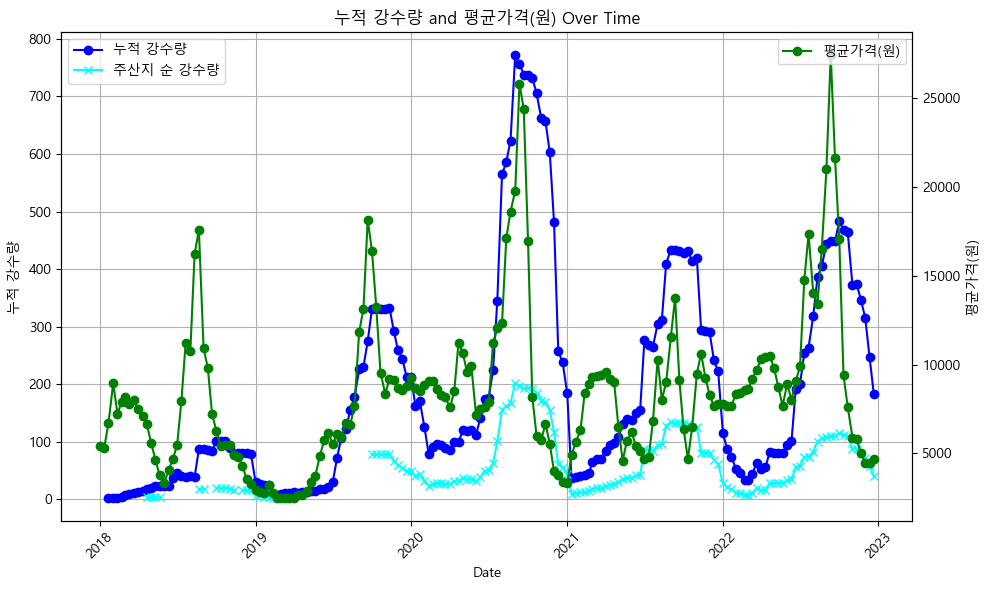

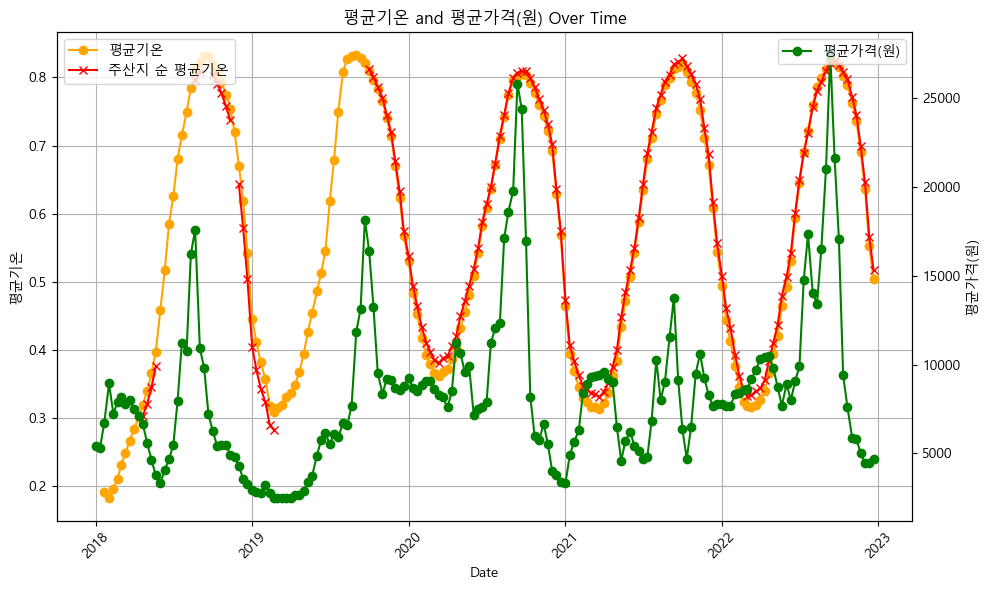

In [19]:
weather_price_plot(cabbage_data)

cabbage_data.columns

## 단수

In [20]:
cabbage_data.columns

Index(['YYYYMMSOON', '가락시장 품목코드(5자리)', '품목(품종)명', '거래단위',
       '등급(특 5% 상 35% 중 40% 하 20%)', '평균가격(원)', '전순 평균가격(원) PreVious SOON',
       '전달 평균가격(원) PreVious MMonth', '전년 평균가격(원) PreVious YeaR',
       '평년 평균가격(원) Common Year SOON', 'year', 'soon', 'date', '품목-품종', '품목명',
       'original_month', 'original_day', 'month_1', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9',
       'month_10', 'month_11', 'month_12', 'day_1', 'day_11', 'day_21', '주산지',
       '지역 이름', '순 강수량', '순 평균기온', '주산지 순 강수량', '주산지 순 평균기온'],
      dtype='object')

In [21]:
def dansu(meta_production, cabbage_data):
    meta_production['단수'] = (meta_production['생산량(톤)'] * 10) / meta_production['재배면적(ha)']
    meta_production['단수'].replace([np.inf, -np.inf], np.nan, inplace=True)
    meta_production = meta_production.rename(columns={'년도': 'year', '품목명': '품목(품종)명'})
    cabbage_data = pd.merge(cabbage_data, meta_production[['year', '품목(품종)명', '단수']], on=['year', '품목(품종)명'], how='left')
    return cabbage_data

cabbage_data = dansu(meta_production, cabbage_data)



C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\1123225057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_production['단수'].replace([np.inf, -np.inf], np.nan, inplace=True)


## 총반입량

In [22]:
meta_nationwide_market = datetime_cov(meta_nationwide_market)

In [23]:
cabbage_data.columns

Index(['YYYYMMSOON', '가락시장 품목코드(5자리)', '품목(품종)명', '거래단위',
       '등급(특 5% 상 35% 중 40% 하 20%)', '평균가격(원)', '전순 평균가격(원) PreVious SOON',
       '전달 평균가격(원) PreVious MMonth', '전년 평균가격(원) PreVious YeaR',
       '평년 평균가격(원) Common Year SOON', 'year', 'soon', 'date', '품목-품종', '품목명',
       'original_month', 'original_day', 'month_1', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9',
       'month_10', 'month_11', 'month_12', 'day_1', 'day_11', 'day_21', '주산지',
       '지역 이름', '순 강수량', '순 평균기온', '주산지 순 강수량', '주산지 순 평균기온', '단수'],
      dtype='object')

In [24]:
meta_nationwide_market.columns

Index(['YYYYMMSOON', '시장코드', '시장명', '품목코드', '품목명', '품종코드', '품종명', '총반입량(kg)',
       '총거래금액(원)', '평균가(원/kg)', '고가(20%) 평균가', '중가(60%) 평균가 ', '저가(20%) 평균가',
       '중간가(원/kg)', '최저가(원/kg)', '최고가(원/kg)', '경매 건수',
       '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth',
       '전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON', '연도', 'year',
       'month', 'soon', 'day', 'date'],
      dtype='object')

In [25]:
meta_production.columns

Index(['년도', '품목명', '재배면적(ha)', '생산량(톤)', '단수'], dtype='object')

In [26]:
def production_in_out_ratio(meta_nationwide_market, meta_production, cabbage_data, product_name):
    # Rename 'original_month' to 'month' for consistency
    cabbage_data = cabbage_data.rename(columns={'original_month': 'month'})
    
    # Calculate total imports for the specified product
    total_import = meta_nationwide_market[
        meta_nationwide_market['품목명'] == product_name
    ].groupby(['year', 'month', 'date']).agg({'총반입량(kg)': 'sum'}).reset_index()
    
    # Merge total_import with cabbage_data on year, month, and date
    cabbage_data = pd.merge(
        cabbage_data,
        total_import,
        on=['year', 'month', 'date'],
        how='left',
        suffixes=('', '_total')
    )

    # Merge production data
    cabbage_data = pd.merge(
        cabbage_data,
        meta_production[['년도', '품목명', '생산량(톤)']],
        left_on=['year', '품목(품종)명'],
        right_on=['년도', '품목명'],
        how='left'
    )
    
    # Calculate the Import-to-Production Ratio
    cabbage_data['반입량_생산량비'] = (
        cabbage_data['총반입량(kg)'] /
        (cabbage_data['생산량(톤)'] * 1000)
    )
    
    # Handle infinite values
    cabbage_data['반입량_생산량비'].replace([np.inf, -np.inf], np.nan, inplace=True)
    
    return cabbage_data


cabbage_data = production_in_out_ratio(meta_nationwide_market, meta_production, cabbage_data, '배추')

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2805904949.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cabbage_data['반입량_생산량비'].replace([np.inf, -np.inf], np.nan, inplace=True)


In [27]:
cabbage_data

,YYYYMMSOON,가락시장 품목코드(5자리),품목(품종)명,거래단위,등급(특 5% 상 35% 중 40% 하 20%),평균가격(원),전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,...,순 강수량,순 평균기온,주산지 순 강수량,주산지 순 평균기온,단수,총반입량(kg),년도,품목명_y,생산량(톤),반입량_생산량비
0,201801상순,21100,배추,10키로망대,상,5419.857143,5293.333333,5242.125000,9213.428571,6071.726190,...,NaN,NaN,NaN,NaN,768.052532,15298460.40,2018,배추,2391946,0.006396
1,201801중순,21100,배추,10키로망대,상,5319.333333,5419.857143,5553.222222,9083.777778,5938.143519,...,NaN,NaN,NaN,NaN,768.052532,14047821.80,2018,배추,2391946,0.005873
2,201801하순,21100,배추,10키로망대,상,6734.777778,5319.333333,5293.333333,8292.166667,6245.351852,...,1.790604,0.191891,NaN,NaN,768.052532,13584056.20,2018,배추,2391946,0.005679
3,201802상순,21100,배추,10키로망대,상,8942.222222,6734.777778,5419.857143,9323.000000,6413.720238,...,2.069799,0.181709,NaN,NaN,768.052532,19202567.40,2018,배추,2391946,0.008028
4,201802중순,21100,배추,10키로망대,상,7247.166667,8942.222222,5319.333333,9243.250000,7099.146825,...,2.182550,0.196018,NaN,NaN,768.052532,12544684.00,2018,배추,2391946,0.005245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,202211중순,21100,배추,10키로망대,상,5806.250000,5895.222222,9403.777778,10626.888889,6978.472222,...,373.508725,0.736173,88.073826,0.744938,720.132953,48523969.82,2022,배추,2199070,0.022066
176,202211하순,21100,배추,10키로망대,상,5000.777778,5806.250000,7601.111111,9273.250000,6712.726852,...,346.092617,0.689963,79.036242,0.698721,720.132953,50752734.70,2022,배추,2199070,0.023079
177,202212상순,21100,배추,10키로망대,상,4451.888889,5000.777778,5895.222222,8281.777778,5946.134259,...,315.220134,0.636252,72.449664,0.645963,720.132953,34723729.40,2022,배추,2199070,0.015790
178,202212중순,21100,배추,10키로망대,상,4487.875000,4451.888889,5806.250000,7667.375000,5667.574074,...,247.460403,0.551778,57.916779,0.565415,720.132953,17215269.10,2022,배추,2199070,0.007828


# 감자 수미

In [28]:
potato_data = train_1[train_1['품목(품종)명'].str.contains('감자 수미', na=False)].copy()
weather_features = potato_data.apply(calculate_weather_features, axis=1)
potato_data = pd.concat([potato_data, weather_features], axis=1)

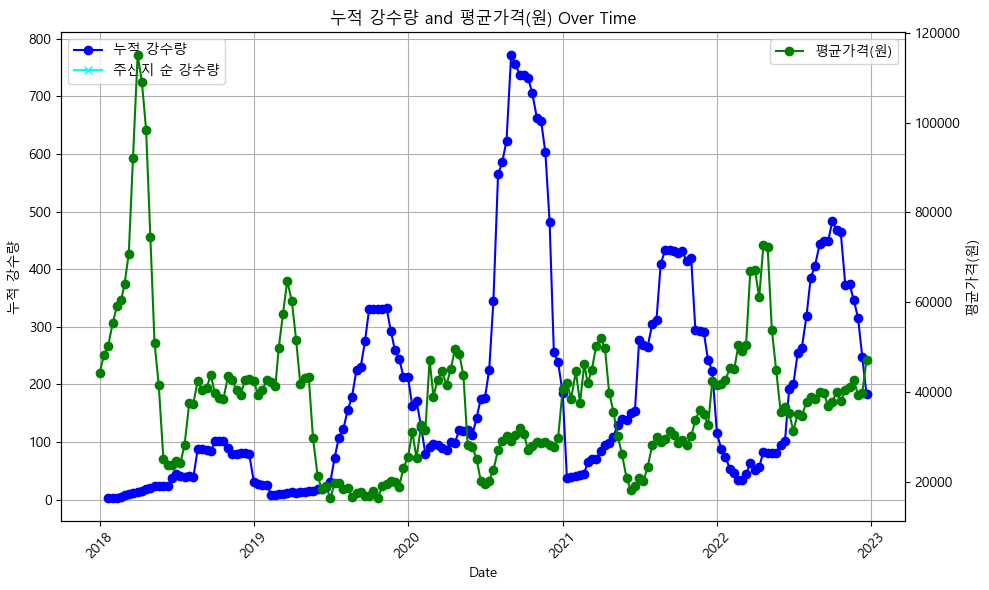

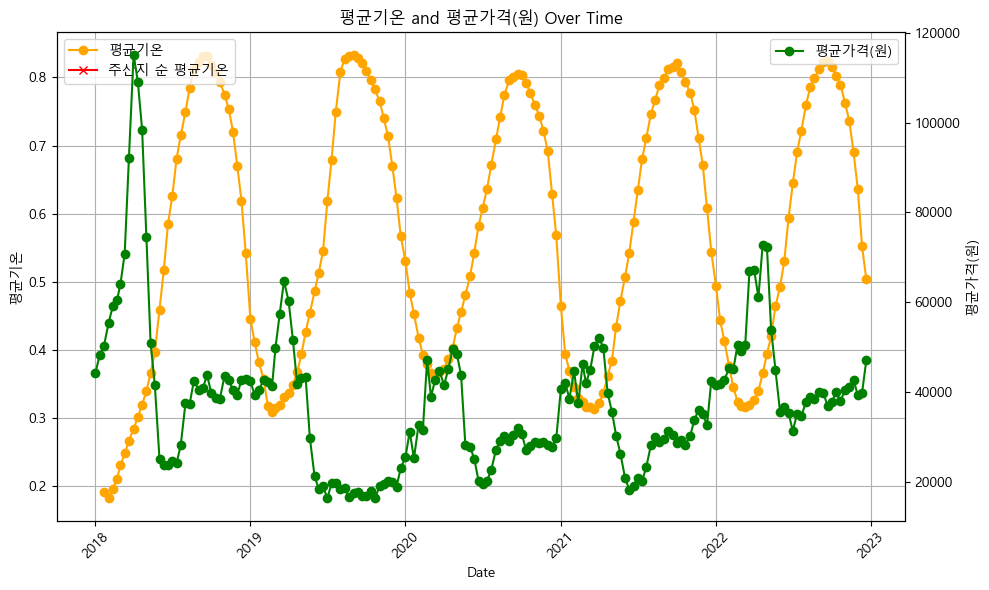

In [29]:
weather_price_plot(potato_data)

In [30]:
potato_data = dansu(meta_production, potato_data)
potato_data = production_in_out_ratio(meta_nationwide_market, meta_production, potato_data, '감자 수미')

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\1123225057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_production['단수'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2805904949.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

# 대파 (일반)

In [36]:
leek_data = train_1[train_1['품목(품종)명'].str.contains('대파(일반)', na=False, regex=False)].copy()
weather_features = leek_data.apply(calculate_weather_features, axis=1)
leek_data = pd.concat([leek_data, weather_features], axis=1)

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2376899542.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  specific_mask = general_mask & (meta_weather['주산지 품목명'].str.contains(row['품목(품종)명'], na=False))


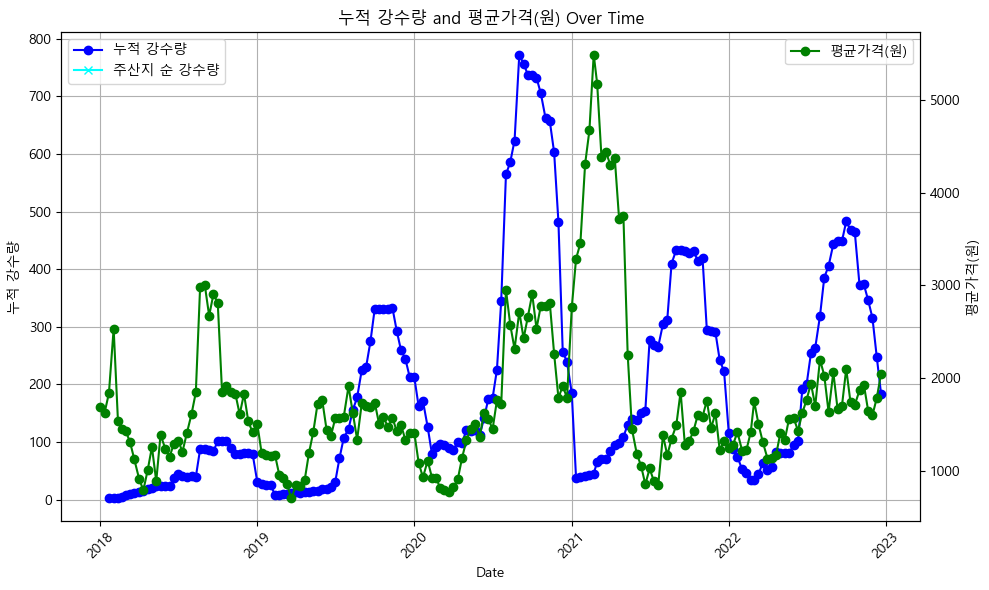

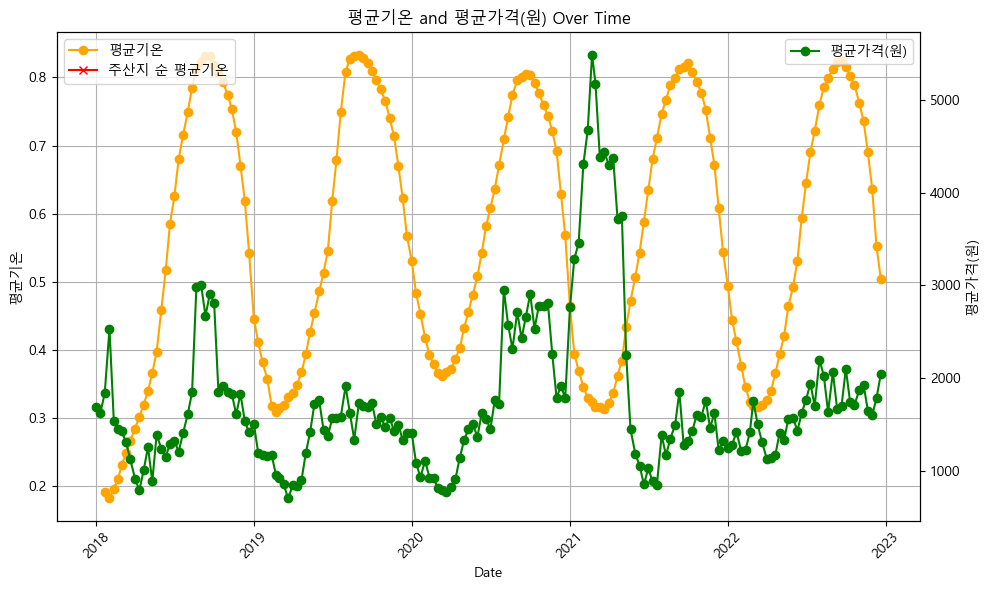

In [39]:
weather_price_plot(leek_data)

In [40]:
leek_data = dansu(meta_production, leek_data)
leek_data = production_in_out_ratio(meta_nationwide_market, meta_production, leek_data, '대파(일반)')

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\1123225057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_production['단수'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2805904949.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

# 무

In [42]:
rad_data = train_1[train_1['품목(품종)명'].str.contains('무', na=False)].copy()
weather_features = rad_data.apply(calculate_weather_features, axis=1)
rad_data = pd.concat([rad_data, weather_features], axis=1)

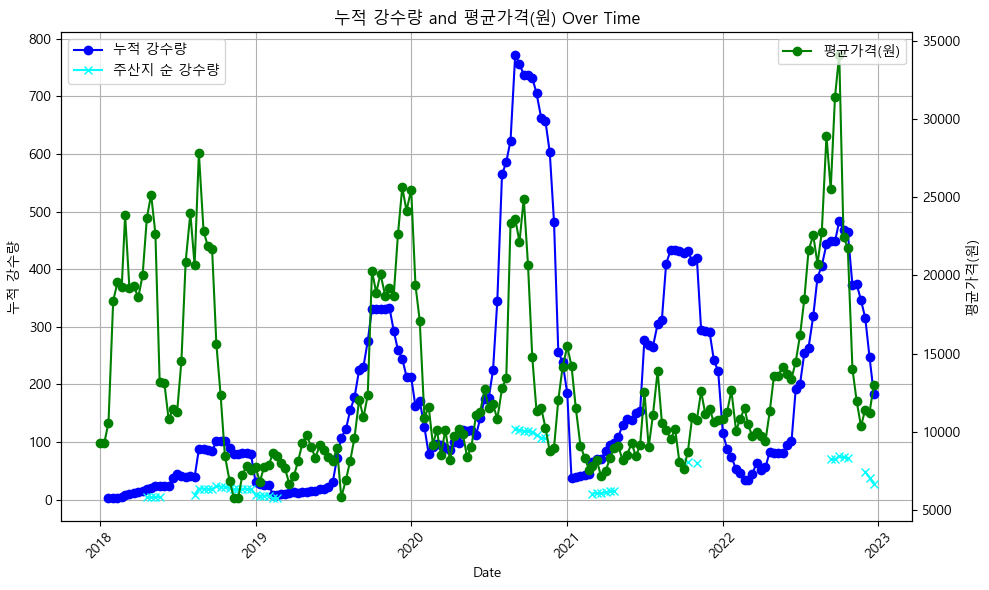

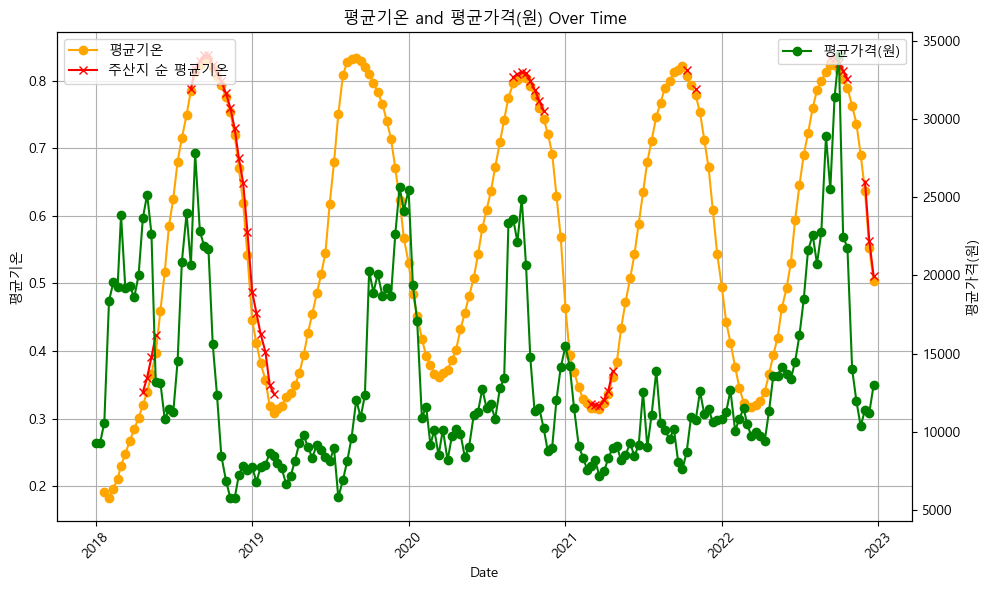

In [43]:
weather_price_plot(rad_data)

In [44]:
rad_data = dansu(meta_production, rad_data)
rad_data = production_in_out_ratio(meta_nationwide_market, meta_production, rad_data, '무')

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\1123225057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_production['단수'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2805904949.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

# 양파

In [45]:
onion_data = train_1[train_1['품목(품종)명'].str.contains('양파', na=False)].copy()
weather_features = onion_data.apply(calculate_weather_features, axis=1)
onion_data = pd.concat([onion_data, weather_features], axis=1)

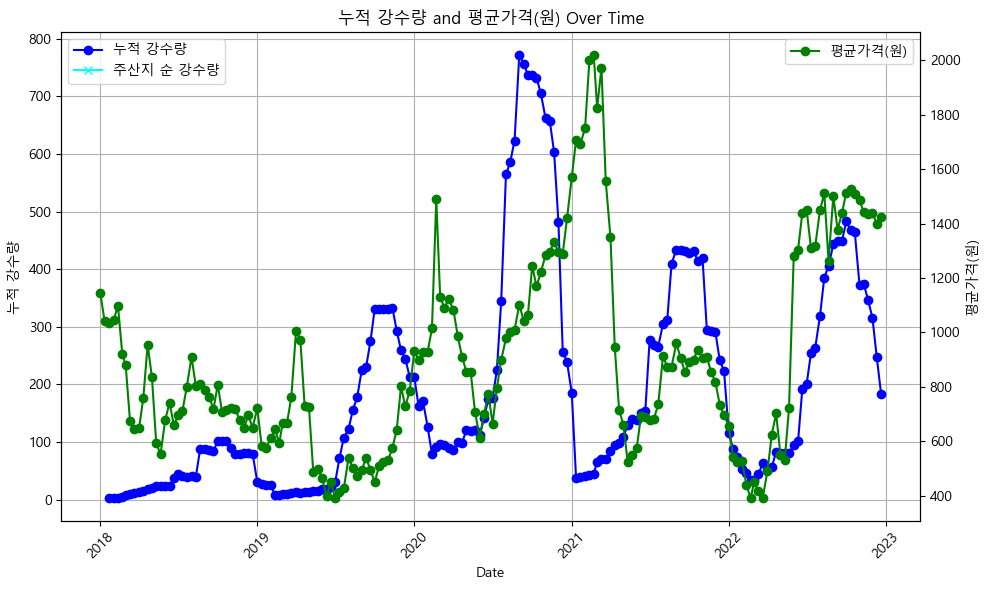

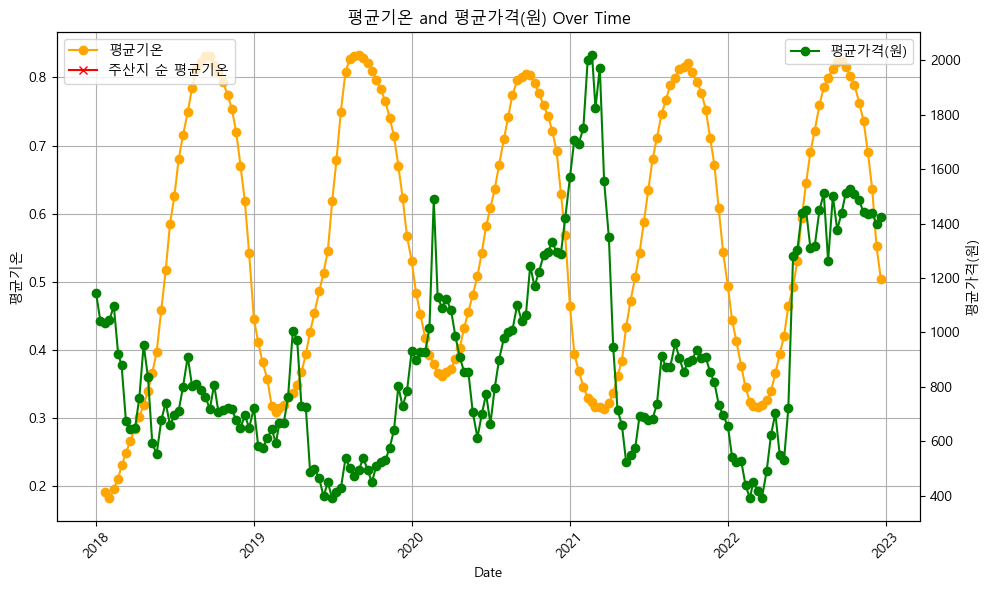

In [46]:
weather_price_plot(onion_data)

In [47]:
onion_data = dansu(meta_production, onion_data)
onion_data = production_in_out_ratio(meta_nationwide_market, meta_production, onion_data, '양파')

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\1123225057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_production['단수'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2805904949.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

# TRAIN 2

In [48]:
train_2['품목(품종)명'] = train_2.apply(lambda x: x['품목명'] if x['품목명'] == x['품종명'] else f"{x['품목명']}({x['품종명']})", axis=1)
train_2

,YYYYMMSOON,품목코드,품목명,품종코드,품종명,등급명,유통단계별 무게,유통단계별 단위,평균가격(원),전순 평균가격(원) PreVious SOON,...,month_7,month_8,month_9,month_10,month_11,month_12,day_1,day_11,day_21,품목(품종)명
0,201801상순,241.0,건고추,0.0,화건,상품,kg,30.0,590000.0,NaN,...,False,False,False,False,False,False,True,False,False,건고추(화건)
1,201801중순,241.0,건고추,0.0,화건,상품,kg,30.0,590000.0,NaN,...,False,False,False,False,False,False,False,True,False,건고추(화건)
2,201801하순,241.0,건고추,0.0,화건,상품,kg,30.0,590000.0,NaN,...,False,False,False,False,False,False,False,False,True,건고추(화건)
3,201802상순,241.0,건고추,0.0,화건,상품,kg,30.0,590000.0,NaN,...,False,False,False,False,False,False,True,False,False,건고추(화건)
4,201802중순,241.0,건고추,0.0,화건,상품,kg,30.0,590000.0,NaN,...,False,False,False,False,False,False,False,True,False,건고추(화건)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,202211중순,412.0,배,1.0,신고,상품,개,10.0,25345.0,NaN,...,False,False,False,False,True,False,False,True,False,배(신고)
896,202211하순,412.0,배,1.0,신고,상품,개,10.0,25689.0,NaN,...,False,False,False,False,True,False,False,False,True,배(신고)
897,202212상순,412.0,배,1.0,신고,상품,개,10.0,25870.0,NaN,...,False,False,False,False,False,True,True,False,False,배(신고)
898,202212중순,412.0,배,1.0,신고,상품,개,10.0,26504.0,NaN,...,False,False,False,False,False,True,False,True,False,배(신고)


# 건고추

In [50]:
pepper_data = train_2[train_2['품목(품종)명'].str.contains('건고추(화건)', na=False, regex=False)].copy()
weather_features = pepper_data.apply(calculate_weather_features, axis=1)
pepper_data = pd.concat([pepper_data, weather_features], axis=1)

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2376899542.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  specific_mask = general_mask & (meta_weather['주산지 품목명'].str.contains(row['품목(품종)명'], na=False))


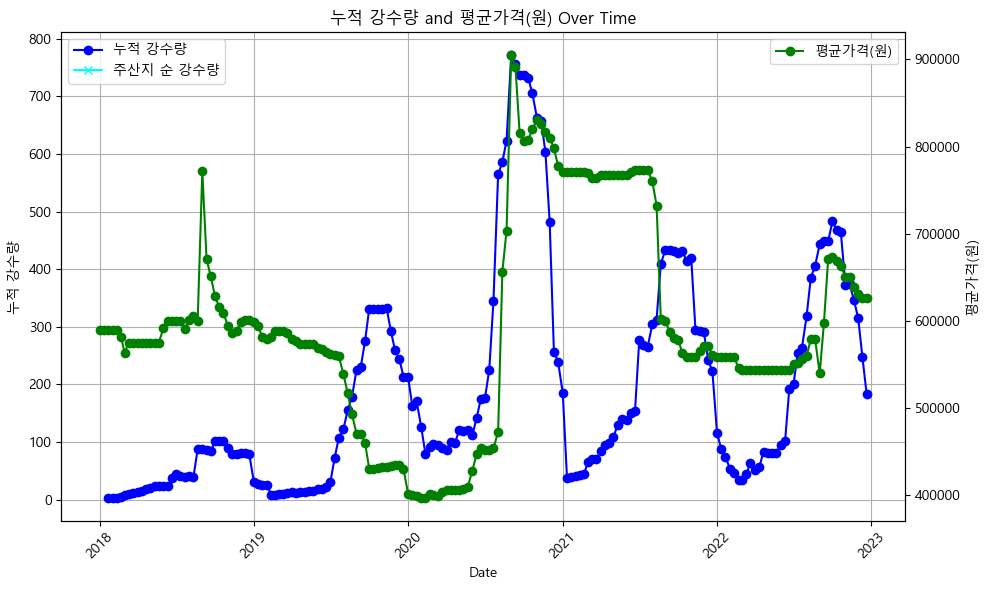

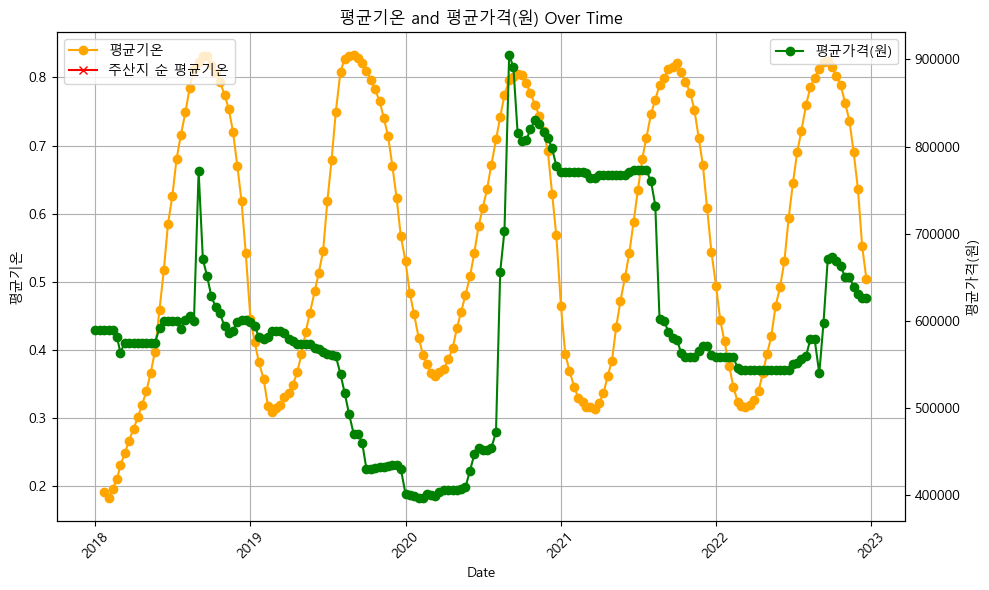

In [51]:
weather_price_plot(pepper_data)

In [52]:
pepper_data = dansu(meta_production, pepper_data)
pepper_data = production_in_out_ratio(meta_nationwide_market, meta_production, pepper_data, '건고추(화건)')

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\1123225057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_production['단수'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2805904949.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

# 깐마늘

In [54]:
garlic_data = train_2[train_2['품목(품종)명'].str.contains('깐마늘(국산)', na=False, regex=False)].copy()
weather_features = garlic_data.apply(calculate_weather_features, axis=1)
garlic_data = pd.concat([garlic_data, weather_features], axis=1)

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2376899542.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  specific_mask = general_mask & (meta_weather['주산지 품목명'].str.contains(row['품목(품종)명'], na=False))


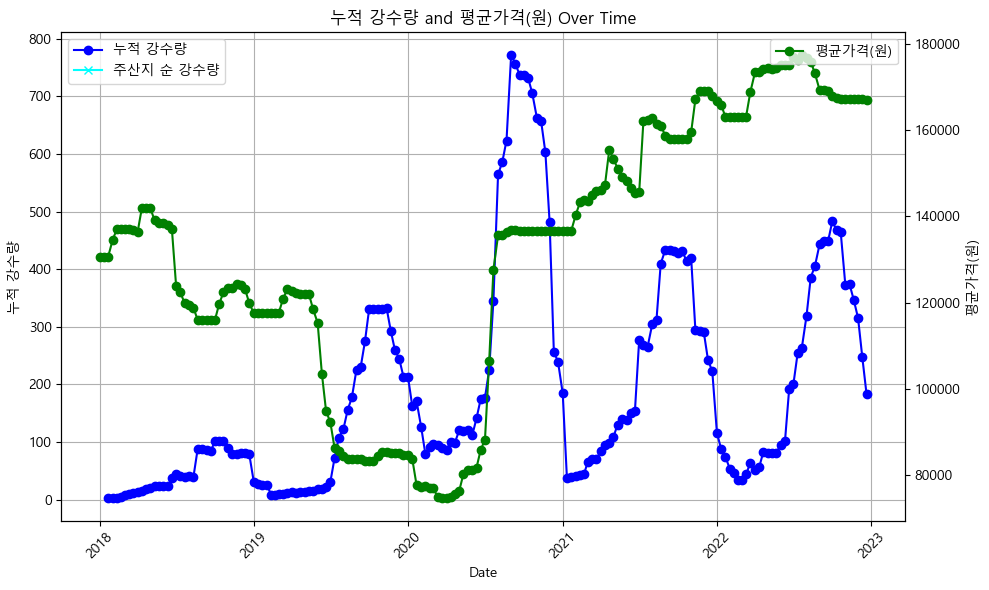

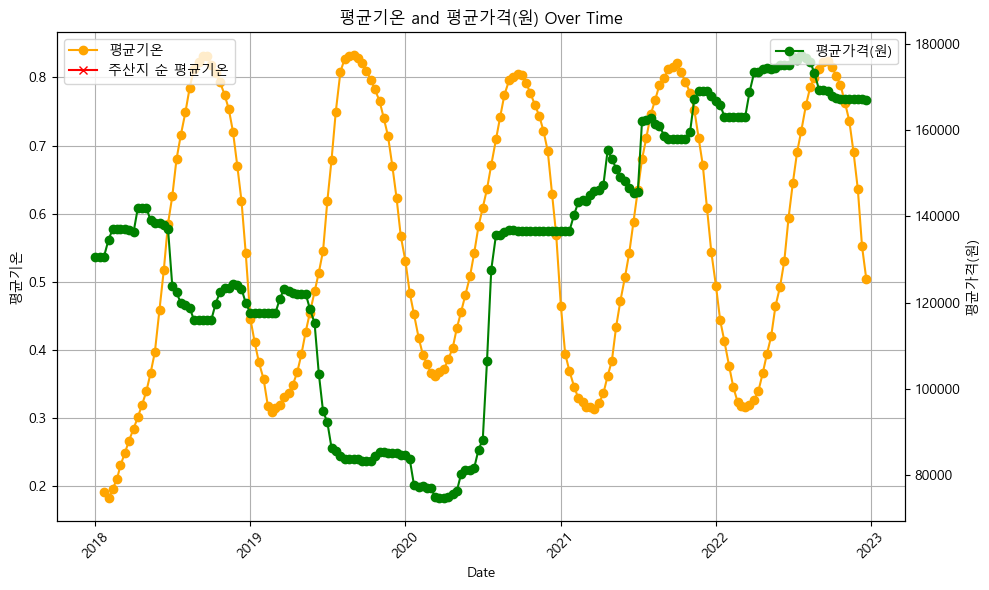

In [55]:
weather_price_plot(garlic_data)

In [56]:
garlic_data = dansu(meta_production, garlic_data)
garlic_data = production_in_out_ratio(meta_nationwide_market, meta_production, garlic_data, '깐마늘(국산)')

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\1123225057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_production['단수'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2805904949.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

# 배

In [57]:
pear_data = train_2[train_2['품목(품종)명'].str.contains('배(신고)', na=False, regex=False)].copy()
weather_features = pear_data.apply(calculate_weather_features, axis=1)
pear_data = pd.concat([pear_data, weather_features], axis=1)

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2376899542.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  specific_mask = general_mask & (meta_weather['주산지 품목명'].str.contains(row['품목(품종)명'], na=False))


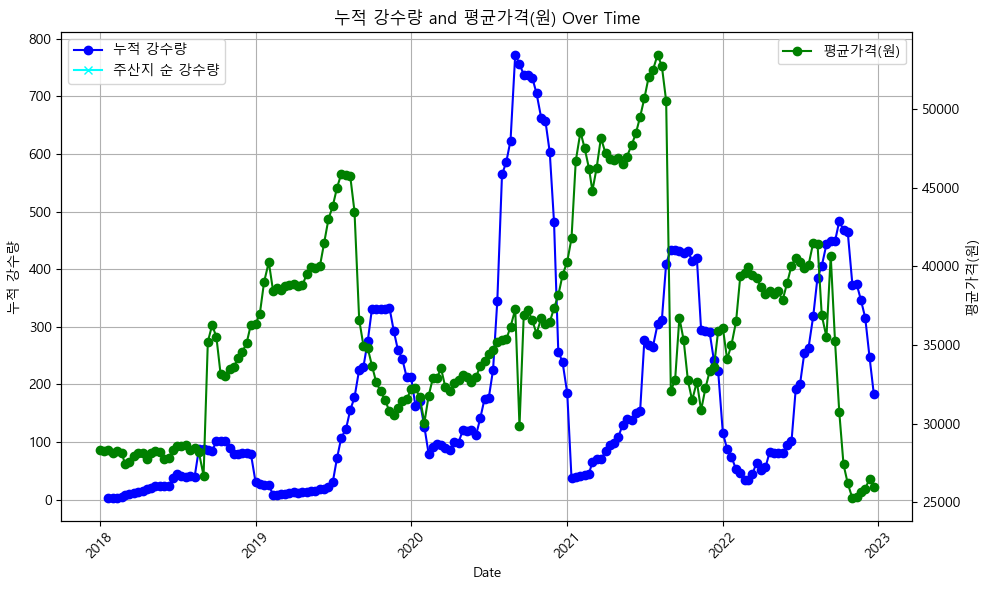

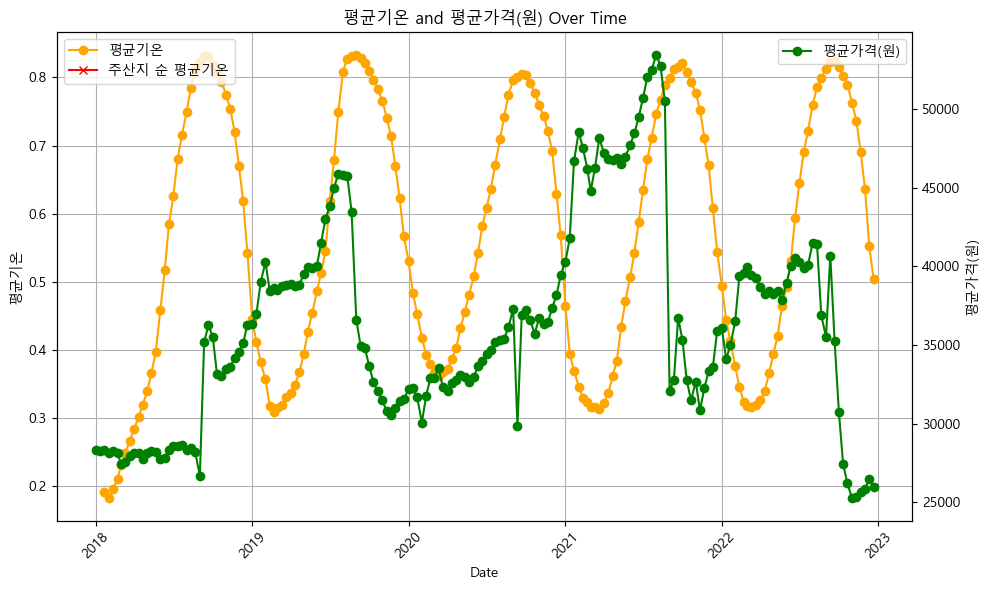

In [58]:
weather_price_plot(pear_data)

In [59]:
pear_data = dansu(meta_production, pear_data)
pear_data = production_in_out_ratio(meta_nationwide_market, meta_production, pear_data, '배(신고)')

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\1123225057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_production['단수'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2805904949.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

# 사과 (우선 결측 없는 홍로로)

In [61]:
apple_data = train_2[train_2['품목(품종)명'].str.contains('사과(홍로)', na=False, regex=False)].copy()
weather_features = apple_data.apply(calculate_weather_features, axis=1)
apple_data = pd.concat([apple_data, weather_features], axis=1)

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2376899542.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  specific_mask = general_mask & (meta_weather['주산지 품목명'].str.contains(row['품목(품종)명'], na=False))


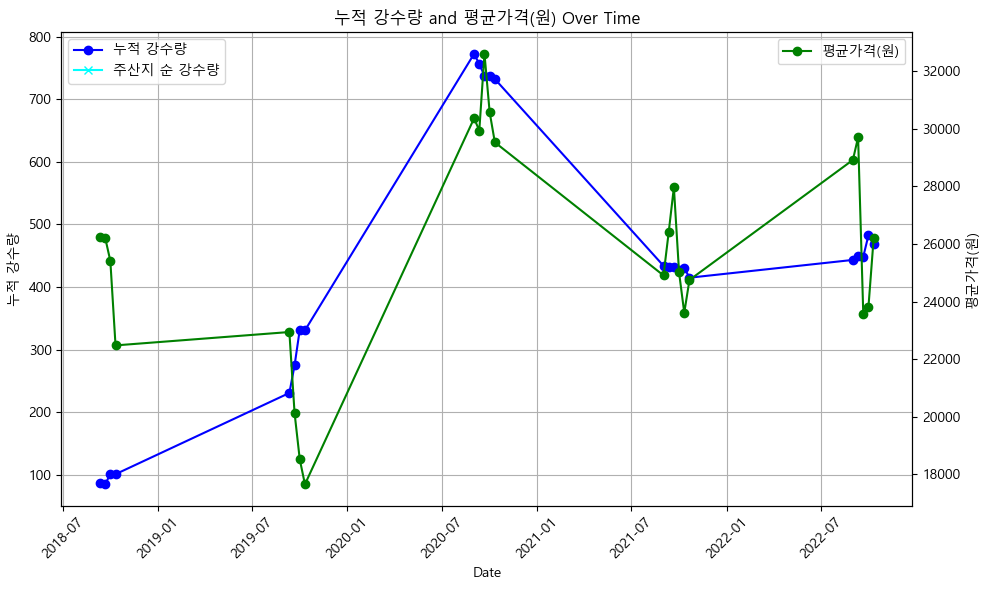

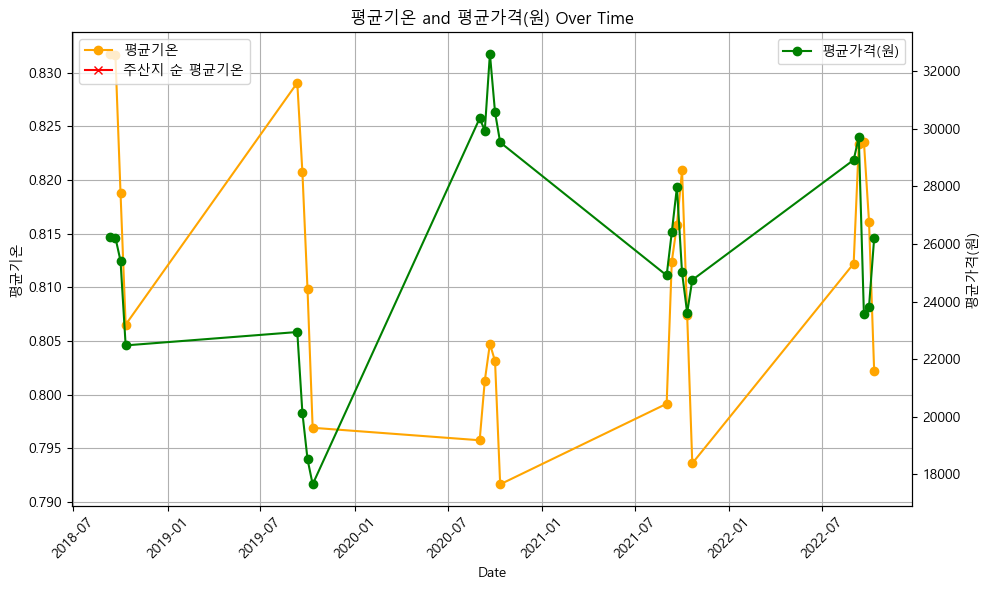

In [62]:
weather_price_plot(apple_data)

In [63]:
apple_data = dansu(meta_production, apple_data)
apple_data = production_in_out_ratio(meta_nationwide_market, meta_production, apple_data, '사과(홍로)')

C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\1123225057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_production['단수'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\dpwl1\AppData\Local\Temp\ipykernel_53836\2805904949.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha